In [1]:
print("hi")

hi


In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset, Dataset
from sklearn.metrics import roc_curve, auc, confusion_matrix, f1_score, precision_score, recall_score, cohen_kappa_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.manifold import TSNE
from torch.optim.lr_scheduler import ReduceLROnPlateau
import copy

# Dataset directory
data_dir = r"/kaggle/input/breast-cancer-detection-using-thermography/BCD_Dataset"
if not os.path.exists(data_dir):
    print(f"Warning: Dataset directory {data_dir} not found. Using placeholder 'BCD_Dataset'.")
    data_dir = "BCD_Dataset"
    os.makedirs(os.path.join(data_dir, "Sick"), exist_ok=True)
    os.makedirs(os.path.join(data_dir, "normal"), exist_ok=True)
    os.makedirs(os.path.join(data_dir, "Unknown_class"), exist_ok=True)

output_dir = "experiment_outputs_best_kappa_per_model"
os.makedirs(output_dir, exist_ok=True)

# --- Dataset Loading and Preprocessing ---
train_loader, val_loader, test_loader = None, None, None
dataset_for_loaders = None
transform = transforms.Compose([
    transforms.Resize((160, 120)),
    transforms.RandomHorizontalFlip(), transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.RandomVerticalFlip(), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class BinaryRemappedDataset(Dataset):
    def __init__(self, subset_from_imagefolder, original_class_to_idx):
        self.subset = subset_from_imagefolder
        self.original_class_to_idx = original_class_to_idx
        self.idx_normal_original = None; self.idx_sick_original = None
        for class_name, idx in self.original_class_to_idx.items():
            if class_name.lower() == 'normal': self.idx_normal_original = idx
            elif class_name.lower() == 'sick': self.idx_sick_original = idx
        if self.idx_normal_original is None: raise ValueError("'normal' class not found. Found: " + str(self.original_class_to_idx.keys()))
        if self.idx_sick_original is None: raise ValueError("'Sick' class not found. Found: " + str(self.original_class_to_idx.keys()))
        self.TARGET_NORMAL = 0; self.TARGET_SICK = 1
        self.classes = ['normal', 'Sick']
    def __getitem__(self, index):
        data, original_label_idx = self.subset[index]
        if original_label_idx == self.idx_normal_original: new_label = self.TARGET_NORMAL
        elif original_label_idx == self.idx_sick_original: new_label = self.TARGET_SICK
        else: raise ValueError(f"Unexpected original_label_idx {original_label_idx}.")
        return data, new_label
    def __len__(self): return len(self.subset)

try:
    full_dataset_imgfolder = datasets.ImageFolder(root=data_dir, transform=transform)
    print(f"Full ImageFolder: Classes: {full_dataset_imgfolder.classes}, Samples: {len(full_dataset_imgfolder.samples)}")
    print(f"Original class_to_idx: {full_dataset_imgfolder.class_to_idx}")
    unknown_class_name_to_filter = 'Unknown_class'
    indices_to_keep = []
    class_idx_to_filter_out = full_dataset_imgfolder.class_to_idx.get(unknown_class_name_to_filter)
    if class_idx_to_filter_out is not None: print(f"'{unknown_class_name_to_filter}' (index {class_idx_to_filter_out}) will be filtered.")
    for i, (image_path, class_idx) in enumerate(full_dataset_imgfolder.samples):
        if class_idx_to_filter_out is not None and class_idx == class_idx_to_filter_out: continue
        indices_to_keep.append(i)
    if not indices_to_keep: raise ValueError(f"No samples remain after filtering.")
    subset_after_filtering = Subset(full_dataset_imgfolder, indices_to_keep)
    dataset_for_loaders = BinaryRemappedDataset(subset_after_filtering, full_dataset_imgfolder.class_to_idx)
    print(f"Filtered Dataset: Classes: {dataset_for_loaders.classes}, Samples: {len(dataset_for_loaders)}")
    if len(dataset_for_loaders.classes) != 2: raise ValueError(f"Final dataset not binary. Found: {dataset_for_loaders.classes}")
    total_samples = len(dataset_for_loaders)
    if total_samples < 3:
        print(f"Warning: Dataset size ({total_samples}) is very small. Using entire dataset for train, val, test.")
        train_dataset, val_dataset, test_dataset = dataset_for_loaders, dataset_for_loaders, dataset_for_loaders
    else:
        train_size = int(0.6 * total_samples); val_size = int(0.2 * total_samples)
        test_size = total_samples - train_size - val_size
        if train_size + val_size + test_size != total_samples: test_size = total_samples - train_size - val_size
        if train_size <= 0 or val_size <= 0 or test_size <= 0: # Ensure non-zero splits
            print(f"Adjusting splits for {total_samples} samples as one was zero...")
            train_size = max(1, int(0.6 * total_samples)); val_size = max(1, int(0.2 * total_samples))
            test_size = max(1, total_samples - train_size - val_size)
            current_sum = train_size + val_size + test_size
            if current_sum != total_samples: # Distribute remainder/deficit to test_size
                test_size += (total_samples - current_sum)
            if train_size <= 0 or val_size <= 0 or test_size <= 0: # Final check
                 print("Critical error in splitting, using duplication.")
                 train_dataset,val_dataset,test_dataset = dataset_for_loaders,dataset_for_loaders,dataset_for_loaders
            else:
                 print(f"Re-adjusted split sizes: Train: {train_size}, Val: {val_size}, Test: {test_size}")
                 train_dataset, val_dataset, test_dataset = random_split(dataset_for_loaders, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))
        else:
            print(f"Calculated split sizes: Train: {train_size}, Val: {val_size}, Test: {test_size}")
            train_dataset, val_dataset, test_dataset = random_split(dataset_for_loaders, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42))
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
    print(f"Samples - Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
    if len(train_dataset) * len(val_dataset) * len(test_dataset) == 0: raise ValueError("A data partition is empty.")
except Exception as e:
    print(f"CRITICAL ERROR during dataset setup: {e}")
    raise RuntimeError(f"Dataset setup failed: {e}") from e

# --- Model Definitions (CNN includes BatchNorm now) ---
class CNN_Model(nn.Module):
    def __init__(self, num_classes=1):
        super(CNN_Model, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1); self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1); self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1); self.bn3 = nn.BatchNorm2d(64)
        flat_size = self._get_conv_output_size((160, 120))
        self.fc1 = nn.Linear(flat_size, 512); self.fc_bn = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, num_classes); self.dropout = nn.Dropout(0.5)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x))); x = F.max_pool2d(x, 2)
        x = F.relu(self.bn2(self.conv2(x))); x = F.max_pool2d(x, 2)
        x = F.relu(self.bn3(self.conv3(x))); x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        features = F.relu(self.fc_bn(self.fc1(x)))
        x_out = self.dropout(features); x_out = torch.sigmoid(self.fc2(x_out))
        return x_out
    def _get_conv_output_size(self, input_size):
        with torch.no_grad():
            x = torch.zeros(1, 3, *input_size)
            x = F.relu(self.bn1(self.conv1(x))); x = F.max_pool2d(x, 2)
            x = F.relu(self.bn2(self.conv2(x))); x = F.max_pool2d(x, 2)
            x = F.relu(self.bn3(self.conv3(x))); x = F.max_pool2d(x, 2)
            return x.view(x.size(0), -1).size(1)
    def get_features(self, x): # For t-SNE
        x = F.relu(self.bn1(self.conv1(x))); x = F.max_pool2d(x, 2)
        x = F.relu(self.bn2(self.conv2(x))); x = F.max_pool2d(x, 2)
        x = F.relu(self.bn3(self.conv3(x))); x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1); features = F.relu(self.fc_bn(self.fc1(x)))
        return features

def get_model(model_name, num_classes=1, pretrained=True): # pretrained for CNN is False effectively
    if model_name == "cnn": model = CNN_Model(num_classes=num_classes)
    elif model_name == "resnet18": model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None); model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "resnet50": model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None); model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif model_name == "densenet121": model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if pretrained else None); model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif model_name == "vgg16": model = models.vgg16(weights=models.VGG16_Weights.DEFAULT if pretrained else None); model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    else: raise ValueError(f"Model {model_name} not recognized.")
    return model

# --- t-SNE Visualization ---
def plot_tsne_for_model(model_instance, model_name_str, data_loader, device, output_path):
    model_instance.eval(); all_features_list, all_labels_list = [], []
    with torch.no_grad():
        for inputs, labels_batch in data_loader:
            inputs = inputs.to(device); features = None
            if model_name_str == "cnn": features = model_instance.get_features(inputs)
            elif "resnet" in model_name_str: feat_extr = nn.Sequential(*list(model_instance.children())[:-1]); features = torch.flatten(feat_extr(inputs), 1)
            elif "densenet" in model_name_str: x = model_instance.features(inputs); x = F.relu(x, inplace=True); x = F.adaptive_avg_pool2d(x, (1, 1)); features = torch.flatten(x, 1)
            elif "vgg" in model_name_str: x = model_instance.features(inputs); x = model_instance.avgpool(x); x = torch.flatten(x, 1); temp_cls = nn.Sequential(*list(model_instance.classifier.children())[:-1]); features = temp_cls(x)
            if features is not None: all_features_list.append(features.cpu().numpy()); all_labels_list.append(labels_batch.cpu().numpy())
    if not all_features_list: print(f"No features for t-SNE for {model_name_str}."); return
    all_features = np.concatenate(all_features_list, axis=0); all_labels = np.concatenate(all_labels_list, axis=0)
    if all_features.shape[0] > 1 and all_features.shape[1] > 0:
        perplexity_val = min(30.0, float(max(1, all_features.shape[0] - 1)))
        tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_val, n_iter=300, init='pca', learning_rate='auto')
        tsne_results = tsne.fit_transform(all_features); plt.figure(figsize=(10, 8))
        scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=all_labels, cmap='coolwarm', alpha=0.7)
        plt.title(f't-SNE for {model_name_str}'); class_names = dataset_for_loaders.classes; unique_lbls = np.unique(all_labels)
        handles = [plt.Line2D([0], [0], marker='o', color='w', label=class_names[i], markerfacecolor=scatter.cmap(scatter.norm(unique_lbls[i]))) for i in range(len(unique_lbls))]
        plt.legend(handles=handles, title="Classes"); plt.savefig(os.path.join(output_path, f"tsne_plot_{model_name_str}.png")); plt.close()
    else: print(f"Not enough samples/features for t-SNE for {model_name_str}. Features: {all_features.shape}")

# --- Main Training Loop ---
model_names_to_train = ["cnn", "resnet18", "densenet121", "resnet50", "vgg16"]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

LEARNING_RATE = 0.00001
NUM_EPOCHS_INITIAL = 20
MAX_ADDITIONAL_EPOCHS_FOR_TARGET = 30 # Max 20 + 30 = 50 total epochs per model
MAX_TOTAL_EPOCHS_PER_MODEL = NUM_EPOCHS_INITIAL + MAX_ADDITIONAL_EPOCHS_FOR_TARGET
TARGET_KAPPA_THRESHOLD = 0.8
EARLY_STOPPING_PATIENCE_KAPPA = 7 # Use the same patience as before

criterion = nn.BCELoss()

for model_name in model_names_to_train:
    print(f"\n{'='*20} Training {model_name.upper()} {'='*20}")
    model_specific_output_dir = os.path.join(output_dir, model_name) # Outputs for this model
    os.makedirs(model_specific_output_dir, exist_ok=True)

    current_model = get_model(model_name, num_classes=1, pretrained=(model_name != "cnn")).to(device)
    optimizer = optim.Adam(current_model.parameters(), lr=LEARNING_RATE)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', patience=3, verbose=False, factor=0.1)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_kappa': []}
    
    best_val_kappa_for_current_model = -float('inf') 
    epochs_no_improve_kappa = 0
    # Path for this specific model's best checkpoint
    best_model_path_current_architecture = os.path.join(model_specific_output_dir, f"best_kappa_model_{model_name}.pth")

    for epoch in range(MAX_TOTAL_EPOCHS_PER_MODEL):
        current_model.train()
        running_train_loss, correct_train, total_train = 0.0, 0, 0
        for inputs, labels in train_loader: # TRAIN STEP
            inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
            optimizer.zero_grad()
            outputs_raw = current_model(inputs)
            outputs = torch.sigmoid(outputs_raw) if model_name != "cnn" else outputs_raw
            loss = criterion(outputs, labels); loss.backward(); optimizer.step()
            running_train_loss += loss.item() * inputs.size(0)
            predicted_binary = (outputs > 0.5).float()
            total_train += labels.size(0); correct_train += (predicted_binary == labels).sum().item()
        epoch_train_loss = running_train_loss / total_train if total_train > 0 else 0
        epoch_train_acc = correct_train / total_train if total_train > 0 else 0
        history['train_loss'].append(epoch_train_loss); history['train_acc'].append(epoch_train_acc)

        current_model.eval() # VALIDATION STEP
        running_val_loss, correct_val, total_val = 0.0, 0, 0
        all_val_labels_list, all_val_preds_binary_list = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels_val = inputs.to(device), labels.to(device).float().unsqueeze(1)
                outputs_raw_val = current_model(inputs)
                outputs_val = torch.sigmoid(outputs_raw_val) if model_name != "cnn" else outputs_raw_val
                loss = criterion(outputs_val, labels_val); running_val_loss += loss.item() * inputs.size(0)
                predicted_binary_val = (outputs_val > 0.5).float()
                total_val += labels_val.size(0); correct_val += (predicted_binary_val == labels_val).sum().item()
                all_val_labels_list.extend(labels_val.cpu().numpy().flatten().tolist())
                all_val_preds_binary_list.extend(predicted_binary_val.cpu().numpy().flatten().tolist())
        
        epoch_val_loss = running_val_loss / total_val if total_val > 0 else 0
        epoch_val_acc = correct_val / total_val if total_val > 0 else 0
        epoch_val_kappa = 0.0
        if total_val > 0 and len(all_val_labels_list) > 0: # Calculate Kappa
            unique_true_val_labels = np.unique(all_val_labels_list)
            if len(unique_true_val_labels) > 1: # Kappa needs more than one true class in val batch
                epoch_val_kappa = cohen_kappa_score(all_val_labels_list, all_val_preds_binary_list)
            elif len(unique_true_val_labels) == 1 and len(np.unique(all_val_preds_binary_list)) == 1 and unique_true_val_labels[0] == np.unique(all_val_preds_binary_list)[0]:
                epoch_val_kappa = 1.0 # Perfect agreement if all true and all pred are the same single class
            else: # Handles cases with single true class and mixed/single different pred class (often results in 0 or low Kappa)
                 epoch_val_kappa = cohen_kappa_score(all_val_labels_list, all_val_preds_binary_list, weights='linear' if len(unique_true_val_labels) == 1 else None)


        history['val_loss'].append(epoch_val_loss); history['val_acc'].append(epoch_val_acc); history['val_kappa'].append(epoch_val_kappa)
        print(f"Model: {model_name} | Epoch {epoch+1}/{MAX_TOTAL_EPOCHS_PER_MODEL} | Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}, Kappa: {epoch_val_kappa:.4f}")

        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(epoch_val_kappa)
        if optimizer.param_groups[0]['lr'] < current_lr:
            print(f"LR reduced to {optimizer.param_groups[0]['lr']:.7f} for {model_name} based on Val Kappa.")

        if epoch_val_kappa > best_val_kappa_for_current_model:
            best_val_kappa_for_current_model = epoch_val_kappa
            epochs_no_improve_kappa = 0
            torch.save(current_model.state_dict(), best_model_path_current_architecture) # Save this model's best
            print(f"Val Kappa improved to {best_val_kappa_for_current_model:.4f} for {model_name}. Model saved.")
        else:
            epochs_no_improve_kappa += 1
            if epochs_no_improve_kappa >= EARLY_STOPPING_PATIENCE_KAPPA:
                print(f"Early stopping for {model_name} at epoch {epoch+1} (Val Kappa not improved for {EARLY_STOPPING_PATIENCE_KAPPA} epochs). Best Val Kappa: {best_val_kappa_for_current_model:.4f}")
                break # Exit training for this model

        # Check after initial epochs if target is met or if we should announce continuation
        if epoch + 1 == NUM_EPOCHS_INITIAL:
            if best_val_kappa_for_current_model < TARGET_KAPPA_THRESHOLD:
                print(f"--- {model_name}: Initial {NUM_EPOCHS_INITIAL} epochs done. Best Kappa {best_val_kappa_for_current_model:.4f} < Target {TARGET_KAPPA_THRESHOLD}. Will continue up to {MAX_TOTAL_EPOCHS_PER_MODEL} epochs if no early stop. ---")
            else:
                print(f"--- {model_name}: Initial {NUM_EPOCHS_INITIAL} epochs done. Best Kappa {best_val_kappa_for_current_model:.4f} >= Target {TARGET_KAPPA_THRESHOLD}. Will continue up to {MAX_TOTAL_EPOCHS_PER_MODEL} epochs if no early stop or further improvement. ---")
        
        # If max total epochs reached (loop will end naturally)
        if epoch + 1 == MAX_TOTAL_EPOCHS_PER_MODEL:
            print(f"--- {model_name}: Reached MAX_TOTAL_EPOCHS_PER_MODEL ({MAX_TOTAL_EPOCHS_PER_MODEL}). Best Val Kappa: {best_val_kappa_for_current_model:.4f} ---")


    print(f"Finished training for {model_name}. Best validation Kappa model saved to {best_model_path_current_architecture}")

    # --- Plotting and Evaluation for the current model ---
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1); plt.plot(history['train_loss'], label='Train Loss'); plt.plot(history['val_loss'], label='Val Loss'); plt.title(f'{model_name} - Loss'); plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend();
    plt.subplot(1, 3, 2); plt.plot(history['train_acc'], label='Train Acc'); plt.plot(history['val_acc'], label='Val Acc'); plt.title(f'{model_name} - Accuracy'); plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend();
    plt.subplot(1, 3, 3); plt.plot(history['val_kappa'], label='Val Kappa'); plt.title(f'{model_name} - Kappa'); plt.xlabel("Epochs"); plt.ylabel("Kappa"); plt.legend();
    plt.tight_layout(); plt.savefig(os.path.join(model_specific_output_dir, f"training_plots_{model_name}.png")); plt.close()

    print(f"\n--- Evaluating {model_name} on Test Set (using its best kappa model) ---")
    if os.path.exists(best_model_path_current_architecture):
        current_model.load_state_dict(torch.load(best_model_path_current_architecture, map_location=device, weights_only=True))
    else: # Should not happen if training occurred
        print(f"Warning: Best kappa model path {best_model_path_current_architecture} not found for {model_name}. Evaluating with last state (if any).")
    current_model.eval()
    
    y_true_test, y_pred_probs_test, y_pred_binary_test = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels_test = inputs.to(device), labels.to(device).float().unsqueeze(1)
            outputs_raw_test = current_model(inputs)
            outputs_test_probs = torch.sigmoid(outputs_raw_test) if model_name != "cnn" else outputs_raw_test
            y_true_test.extend(labels_test.cpu().numpy().flatten().tolist())
            y_pred_probs_test.extend(outputs_test_probs.cpu().numpy().flatten().tolist())
            y_pred_binary_test.extend((outputs_test_probs > 0.5).float().cpu().numpy().flatten().tolist())

    if not y_true_test: print(f"No test predictions for {model_name}."); continue

    report_path = os.path.join(model_specific_output_dir, f"classification_report_{model_name}.txt")
    target_names_report = dataset_for_loaders.classes
    report_str = classification_report(y_true_test, y_pred_binary_test, target_names=target_names_report, zero_division=0)
    print(f"Classification Report for {model_name}:\n{report_str}")
    with open(report_path, "w") as f: f.write(f"Classification Report for {model_name}:\n{report_str}")
    
    test_kappa = cohen_kappa_score(y_true_test, y_pred_binary_test)
    f1_w = f1_score(y_true_test, y_pred_binary_test, average="weighted", zero_division=0)
    precision_w = precision_score(y_true_test, y_pred_binary_test, average="weighted", zero_division=0)
    recall_w = recall_score(y_true_test, y_pred_binary_test, average="weighted", zero_division=0)
    print(f'Test Kappa Score for {model_name}: {test_kappa:.4f}')
    with open(report_path, "a") as f: f.write(f'\nTest Kappa Score: {test_kappa:.4f}\nF1 (Weighted): {f1_w:.4f}\nPrecision (Weighted): {precision_w:.4f}\nRecall (Weighted): {recall_w:.4f}\n')

    cm = confusion_matrix(y_true_test, y_pred_binary_test); plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names_report, yticklabels=target_names_report)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'Confusion Matrix - {model_name}')
    plt.savefig(os.path.join(model_specific_output_dir, f"confusion_matrix_{model_name}.png")); plt.close()

    if y_pred_probs_test and len(np.unique(y_true_test)) > 1 :
        fpr, tpr, _ = roc_curve(y_true_test, y_pred_probs_test); roc_auc = auc(fpr, tpr); plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--'); plt.xlabel('FPR'); plt.ylabel('TPR')
        plt.title(f'ROC Curve - {model_name}'); plt.legend(loc="lower right")
        plt.savefig(os.path.join(model_specific_output_dir, f"roc_curve_{model_name}.png")); plt.close()
    else: print(f"Could not plot ROC for {model_name} (Test set y_true may have only 1 class or no predictions).")

    print(f"\n--- Generating t-SNE for {model_name} (using its best kappa model) ---")
    plot_tsne_for_model(current_model, model_name, test_loader, device, model_specific_output_dir)

print(f"\nAll models trained. Best versions (based on Val Kappa) saved in their respective subdirectories within '{output_dir}'.")

Full ImageFolder: Classes: ['Sick', 'Unknown_class', 'normal'], Samples: 362
Original class_to_idx: {'Sick': 0, 'Unknown_class': 1, 'normal': 2}
'Unknown_class' (index 1) will be filtered.
Filtered Dataset: Classes: ['normal', 'Sick'], Samples: 262
Calculated split sizes: Train: 157, Val: 52, Test: 53
Samples - Train: 157, Val: 52, Test: 53
Using device: cuda

==================== Training CNN ====================


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Model: cnn | Epoch 1/50 | Train Loss: 0.6426, Acc: 0.6242 | Val Loss: 0.7025, Acc: 0.3846, Kappa: 0.0048
Val Kappa improved to 0.0048 for cnn. Model saved.
Model: cnn | Epoch 2/50 | Train Loss: 0.6409, Acc: 0.5732 | Val Loss: 0.7011, Acc: 0.4808, Kappa: 0.1501
Val Kappa improved to 0.1501 for cnn. Model saved.
Model: cnn | Epoch 3/50 | Train Loss: 0.6343, Acc: 0.6306 | Val Loss: 0.6959, Acc: 0.5385, Kappa: 0.2161
Val Kappa improved to 0.2161 for cnn. Model saved.
Model: cnn | Epoch 4/50 | Train Loss: 0.6037, Acc: 0.7006 | Val Loss: 0.6450, Acc: 0.7308, Kappa: 0.4770
Val Kappa improved to 0.4770 for cnn. Model saved.
Model: cnn | Epoch 5/50 | Train Loss: 0.5987, Acc: 0.7070 | Val Loss: 0.5976, Acc: 0.7500, Kappa: 0.4925
Val Kappa improved to 0.4925 for cnn. Model saved.
Model: cnn | Epoch 6/50 | Train Loss: 0.5898, Acc: 0.6624 | Val Loss: 0.5812, Acc: 0.7308, Kappa: 0.4277
Model: cnn | Epoch 7/50 | Train Loss: 0.5373, Acc: 0.7452 | Val Loss: 0.5343, Acc: 0.8269, Kappa: 0.6139
Val Kappa 

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Model: resnet18 | Epoch 1/50 | Train Loss: 0.6968, Acc: 0.5987 | Val Loss: 0.6282, Acc: 0.6923, Kappa: 0.0000
Val Kappa improved to 0.0000 for resnet18. Model saved.
Model: resnet18 | Epoch 2/50 | Train Loss: 0.6908, Acc: 0.5987 | Val Loss: 0.6121, Acc: 0.6346, Kappa: -0.0165
Model: resnet18 | Epoch 3/50 | Train Loss: 0.6650, Acc: 0.6242 | Val Loss: 0.5704, Acc: 0.7500, Kappa: 0.2747
Val Kappa improved to 0.2747 for resnet18. Model saved.
Model: resnet18 | Epoch 4/50 | Train Loss: 0.6421, Acc: 0.6624 | Val Loss: 0.5166, Acc: 0.7692, Kappa: 0.3158
Val Kappa improved to 0.3158 for resnet18. Model saved.
Model: resnet18 | Epoch 5/50 | Train Loss: 0.6029, Acc: 0.7261 | Val Loss: 0.4783, Acc: 0.7692, Kappa: 0.3953
Val Kappa improved to 0.3953 for resnet18. Model saved.
Model: resnet18 | Epoch 6/50 | Train Loss: 0.5499, Acc: 0.7580 | Val Loss: 0.5370, Acc: 0.7308, Kappa: 0.2946
Model: resnet18 | Epoch 7/50 | Train Loss: 0.5537, Acc: 0.7707 | Val Loss: 0.5150, Acc: 0.7692, Kappa: 0.3953
Model

...

Model: densenet121 | Epoch 1/50 | Train Loss: 0.7224, Acc: 0.5032 | Val Loss: 0.6369, Acc: 0.6538, Kappa: -0.0263
Val Kappa improved to -0.0263 for densenet121. Model saved.
Model: densenet121 | Epoch 2/50 | Train Loss: 0.6825, Acc: 0.6051 | Val Loss: 0.6000, Acc: 0.7308, Kappa: 0.1651
Val Kappa improved to 0.1651 for densenet121. Model saved.
Model: densenet121 | Epoch 3/50 | Train Loss: 0.6482, Acc: 0.5860 | Val Loss: 0.6073, Acc: 0.7115, Kappa: 0.1975
Val Kappa improved to 0.1975 for densenet121. Model saved.
Model: densenet121 | Epoch 4/50 | Train Loss: 0.6458, Acc: 0.6242 | Val Loss: 0.5962, Acc: 0.7115, Kappa: 0.2586
Val Kappa improved to 0.2586 for densenet121. Model saved.
Model: densenet121 | Epoch 5/50 | Train Loss: 0.6341, Acc: 0.6752 | Val Loss: 0.5690, Acc: 0.7692, Kappa: 0.4179
Val Kappa improved to 0.4179 for densenet121. Model saved.
Model: densenet121 | Epoch 6/50 | Train Loss: 0.6176, Acc: 0.6688 | Val Loss: 0.5745, Acc: 0.6731, Kappa: 0.1597
Model: densenet121 | Epoc

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Model: resnet50 | Epoch 1/50 | Train Loss: 0.6959, Acc: 0.4968 | Val Loss: 0.7132, Acc: 0.4423, Kappa: 0.0645
Val Kappa improved to 0.0645 for resnet50. Model saved.
Model: resnet50 | Epoch 2/50 | Train Loss: 0.6882, Acc: 0.5032 | Val Loss: 0.6988, Acc: 0.4808, Kappa: 0.0836
Val Kappa improved to 0.0836 for resnet50. Model saved.
Model: resnet50 | Epoch 3/50 | Train Loss: 0.6803, Acc: 0.5924 | Val Loss: 0.6764, Acc: 0.6538, Kappa: 0.3464
Val Kappa improved to 0.3464 for resnet50. Model saved.
Model: resnet50 | Epoch 4/50 | Train Loss: 0.6910, Acc: 0.5223 | Val Loss: 0.6793, Acc: 0.5962, Kappa: 0.2479
Model: resnet50 | Epoch 5/50 | Train Loss: 0.6836, Acc: 0.5669 | Val Loss: 0.6909, Acc: 0.5962, Kappa: 0.1802
Model: resnet50 | Epoch 6/50 | Train Loss: 0.6820, Acc: 0.5669 | Val Loss: 0.6687, Acc: 0.7308, Kappa: 0.4451
Val Kappa improved to 0.4451 for resnet50. Model saved.
Model: resnet50 | Epoch 7/50 | Train Loss: 0.6789, Acc: 0.6051 | Val Loss: 0.6683, Acc: 0.6538, Kappa: 0.2866
Model:

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Model: vgg16 | Epoch 1/50 | Train Loss: 0.6923, Acc: 0.6051 | Val Loss: 0.5822, Acc: 0.7308, Kappa: 0.2018
Val Kappa improved to 0.2018 for vgg16. Model saved.
Model: vgg16 | Epoch 2/50 | Train Loss: 0.6439, Acc: 0.6433 | Val Loss: 0.5906, Acc: 0.7115, Kappa: 0.1631
Model: vgg16 | Epoch 3/50 | Train Loss: 0.6117, Acc: 0.6624 | Val Loss: 0.5293, Acc: 0.8269, Kappa: 0.5375
Val Kappa improved to 0.5375 for vgg16. Model saved.
Model: vgg16 | Epoch 4/50 | Train Loss: 0.5855, Acc: 0.7389 | Val Loss: 0.5139, Acc: 0.8462, Kappa: 0.6119
Val Kappa improved to 0.6119 for vgg16. Model saved.
Model: vgg16 | Epoch 5/50 | Train Loss: 0.5493, Acc: 0.7516 | Val Loss: 0.4513, Acc: 0.8846, Kappa: 0.6977
Val Kappa improved to 0.6977 for vgg16. Model saved.
Model: vgg16 | Epoch 6/50 | Train Loss: 0.5241, Acc: 0.7707 | Val Loss: 0.4434, Acc: 0.8462, Kappa: 0.6119
Model: vgg16 | Epoch 7/50 | Train Loss: 0.4890, Acc: 0.7643 | Val Loss: 0.4292, Acc: 0.8654, Kappa: 0.6540
Model: vgg16 | Epoch 8/50 | Train Loss:

In [6]:
import os
import zipfile

def zip_directory(folder_path, output_zip_path):
    """
    Zips the contents of an entire folder.

    Args:
        folder_path (str): The path to the folder to be zipped.
        output_zip_path (str): The path for the output zip file (e.g., 'archive.zip').
    """
    try:
        with zipfile.ZipFile(output_zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            # Walk through the directory
            for root, dirs, files in os.walk(folder_path):
                for file in files:
                    # Create the full path to the file
                    file_path = os.path.join(root, file)
                    # Create the relative path for the archive
                    # This ensures the directory structure is maintained inside the zip
                    archive_path = os.path.relpath(file_path, os.path.dirname(folder_path)) # Use os.path.dirname to get parent
                    print(f"Adding {file_path} as {archive_path} to zip...")
                    zipf.write(file_path, arcname=archive_path)
        print(f"Successfully created zip file: {output_zip_path}")
    except Exception as e:
        print(f"Error creating zip file: {e}")

# Your output directory
output_dir_to_zip = "experiment_outputs_best_kappa_per_model"
zip_file_name = "experiment_outputs_best_kappa_per_model.zip" # Name of the zip file

# Check if the directory exists
if os.path.isdir(output_dir_to_zip):
    zip_directory(output_dir_to_zip, zip_file_name)
    print(f"\nTo download '{zip_file_name}', locate it in your current working directory.")
    # If in Google Colab, you can use:
    # from google.colab import files
    # files.download(zip_file_name)
else:
    print(f"Error: Directory '{output_dir_to_zip}' not found.")

Adding experiment_outputs_best_kappa_per_model/cnn/confusion_matrix_cnn.png as experiment_outputs_best_kappa_per_model/cnn/confusion_matrix_cnn.png to zip...
Adding experiment_outputs_best_kappa_per_model/cnn/roc_curve_cnn.png as experiment_outputs_best_kappa_per_model/cnn/roc_curve_cnn.png to zip...
Adding experiment_outputs_best_kappa_per_model/cnn/classification_report_cnn.txt as experiment_outputs_best_kappa_per_model/cnn/classification_report_cnn.txt to zip...
Adding experiment_outputs_best_kappa_per_model/cnn/training_plots_cnn.png as experiment_outputs_best_kappa_per_model/cnn/training_plots_cnn.png to zip...
Adding experiment_outputs_best_kappa_per_model/cnn/tsne_plot_cnn.png as experiment_outputs_best_kappa_per_model/cnn/tsne_plot_cnn.png to zip...
Adding experiment_outputs_best_kappa_per_model/cnn/best_kappa_model_cnn.pth as experiment_outputs_best_kappa_per_model/cnn/best_kappa_model_cnn.pth to zip...
Adding experiment_outputs_best_kappa_per_model/densenet121/roc_curve_dense

Attempting to display plots from: /kaggle/working/experiment_outputs_best_kappa_per_model



Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/cnn/training_plots_cnn.png


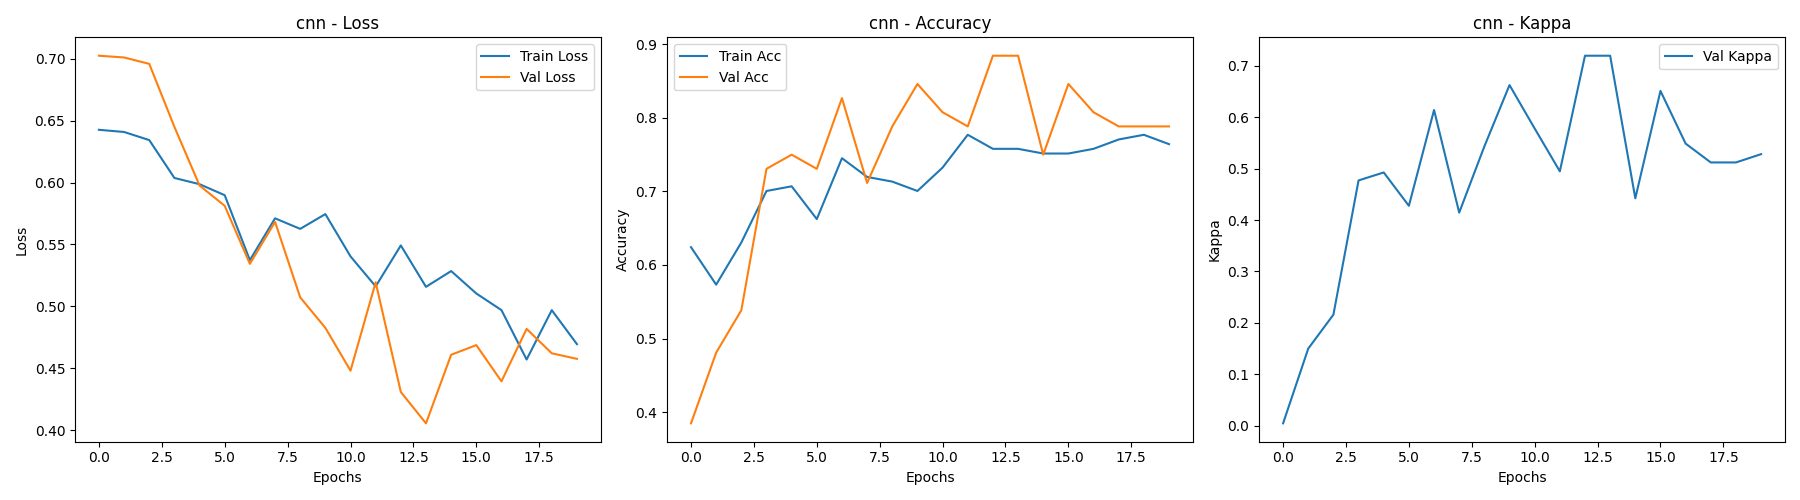

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/cnn/confusion_matrix_cnn.png


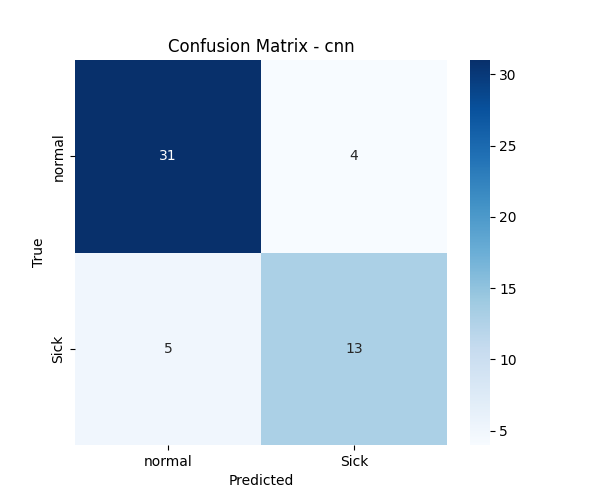

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/cnn/roc_curve_cnn.png


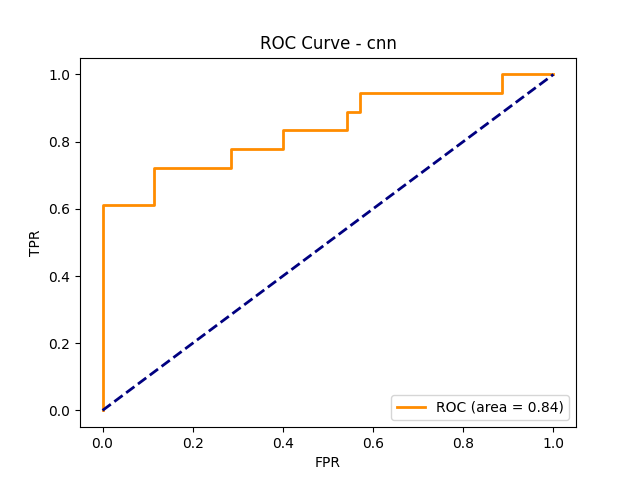

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/cnn/tsne_plot_cnn.png


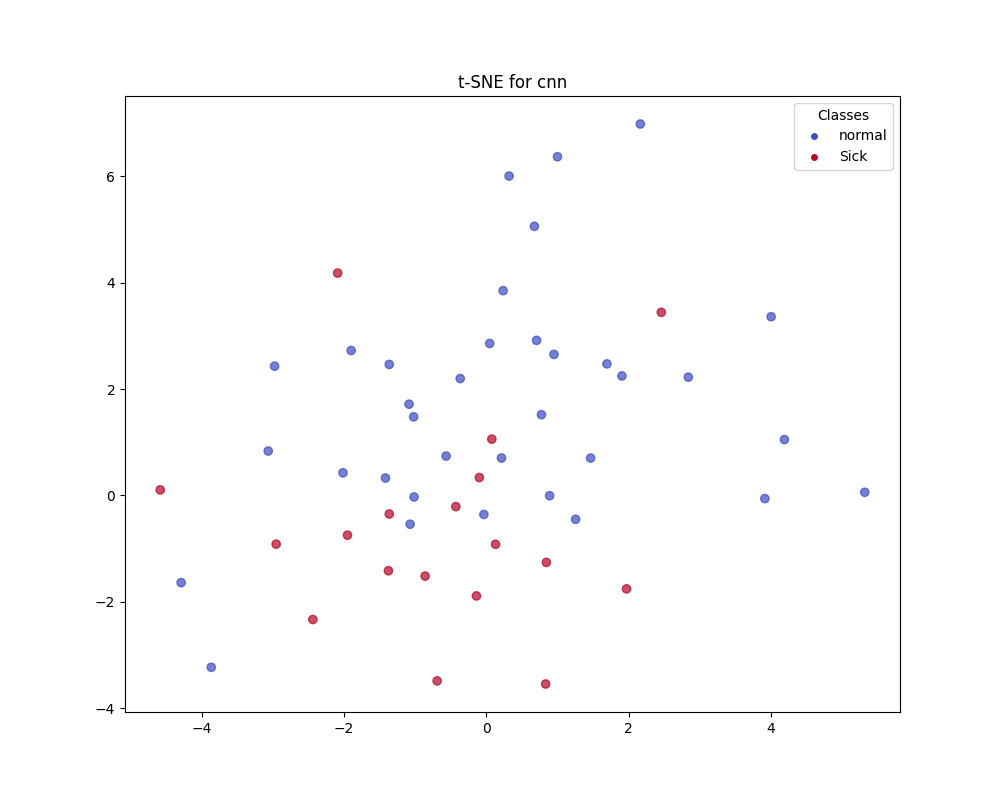

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/resnet18/training_plots_resnet18.png


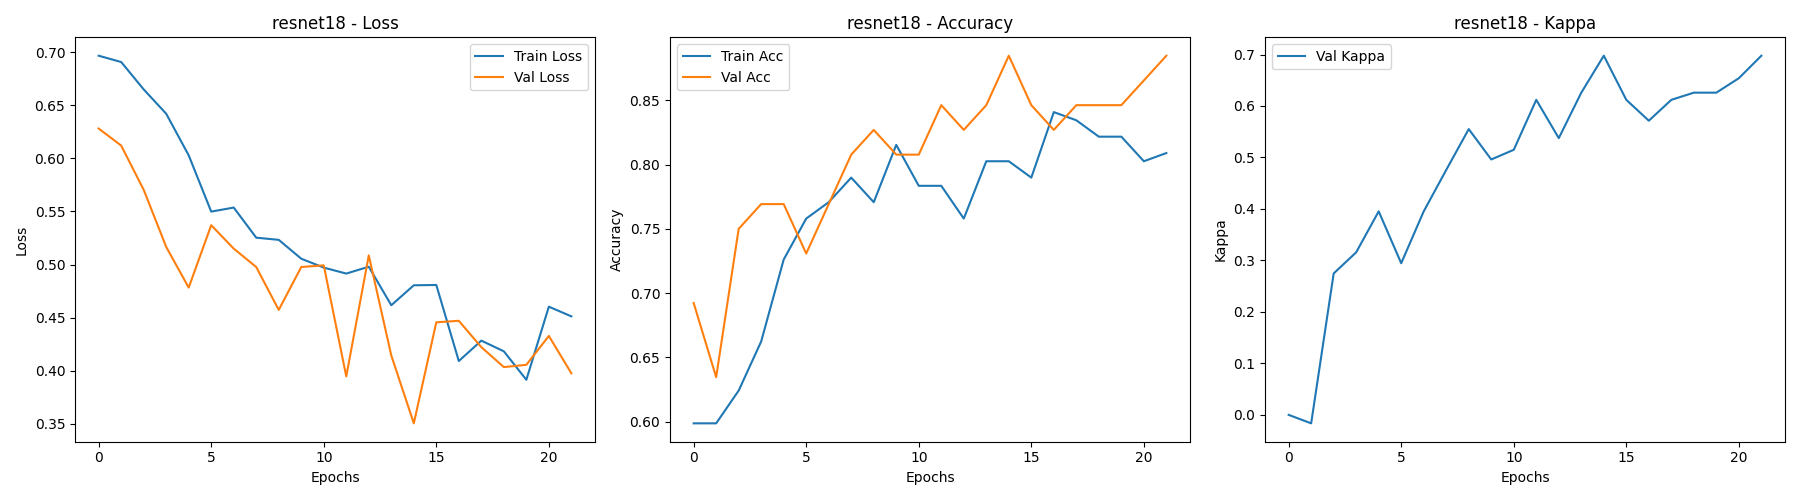

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/resnet18/confusion_matrix_resnet18.png


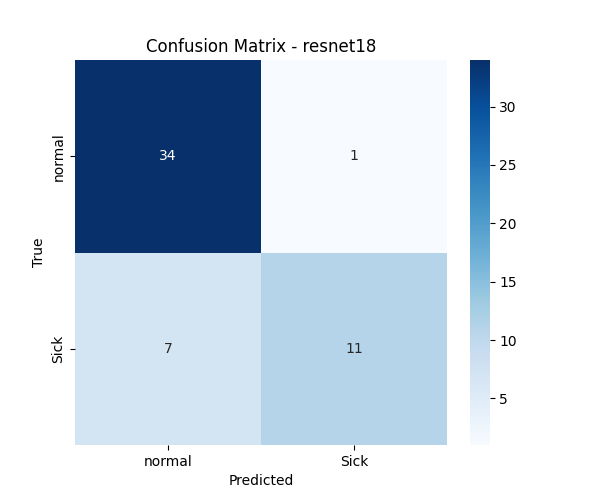

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/resnet18/roc_curve_resnet18.png


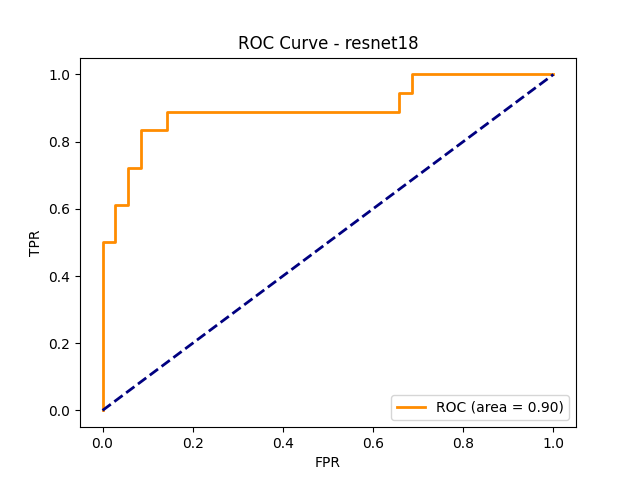

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/resnet18/tsne_plot_resnet18.png


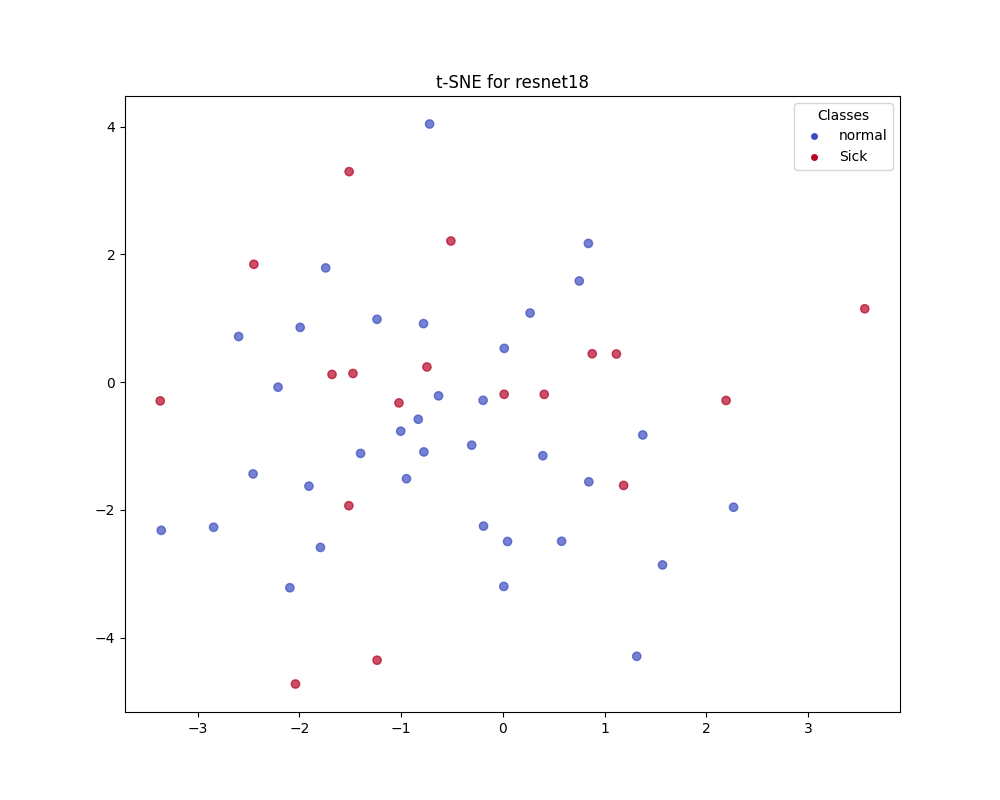

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/densenet121/training_plots_densenet121.png


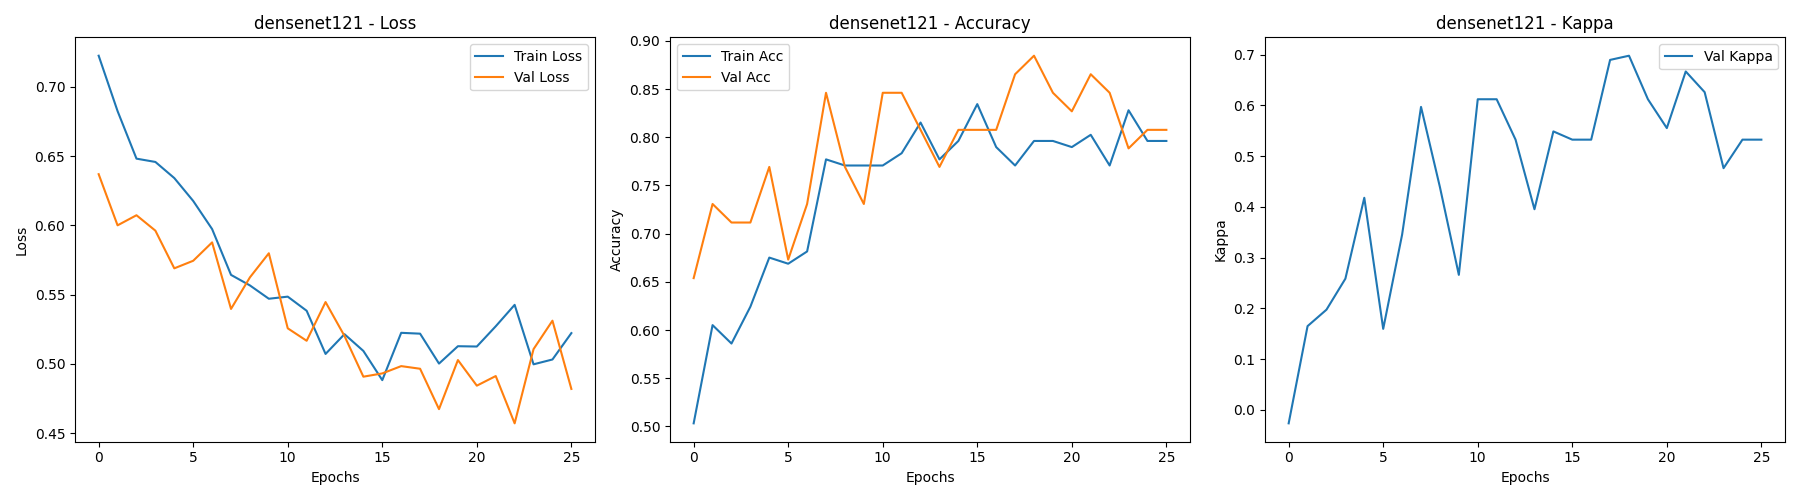

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/densenet121/confusion_matrix_densenet121.png


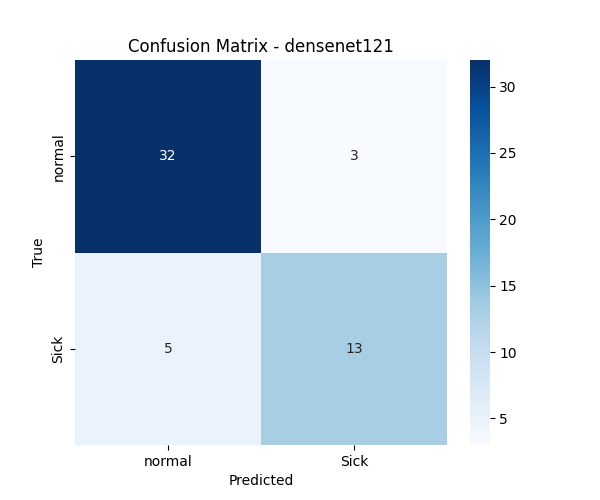

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/densenet121/roc_curve_densenet121.png


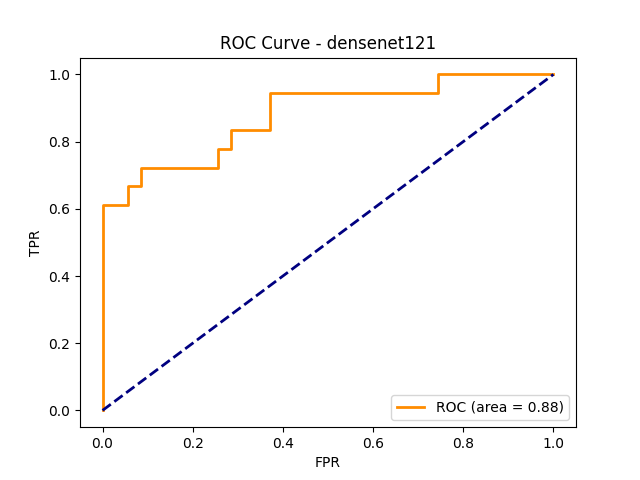

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/densenet121/tsne_plot_densenet121.png


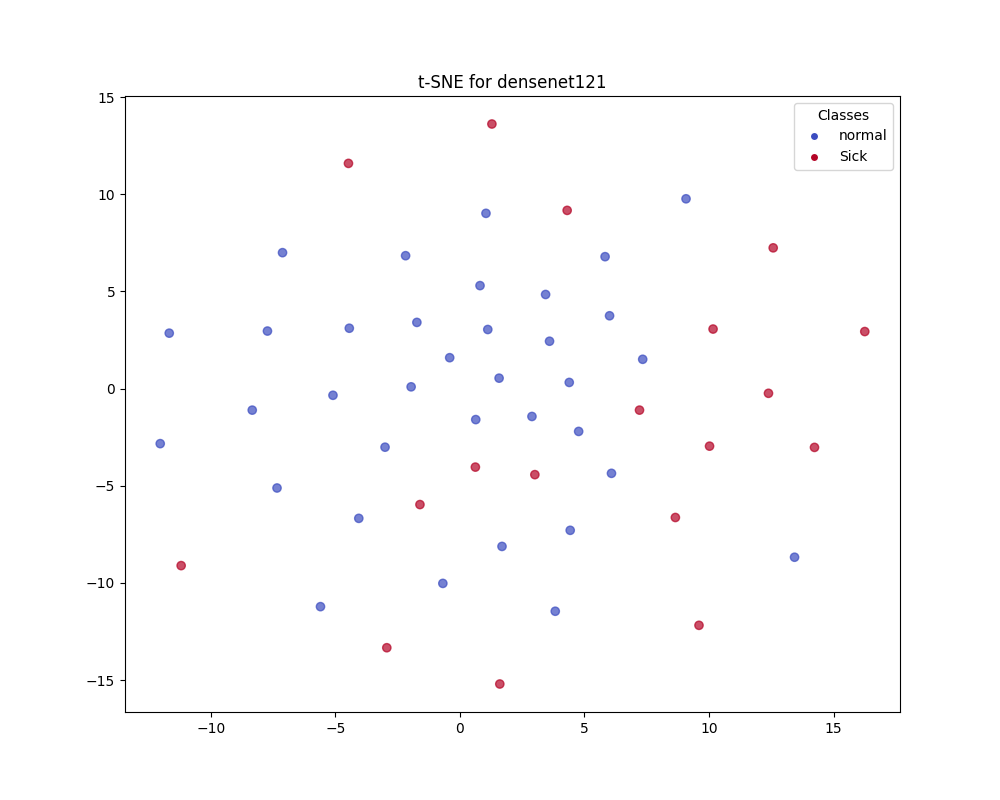

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/resnet50/training_plots_resnet50.png


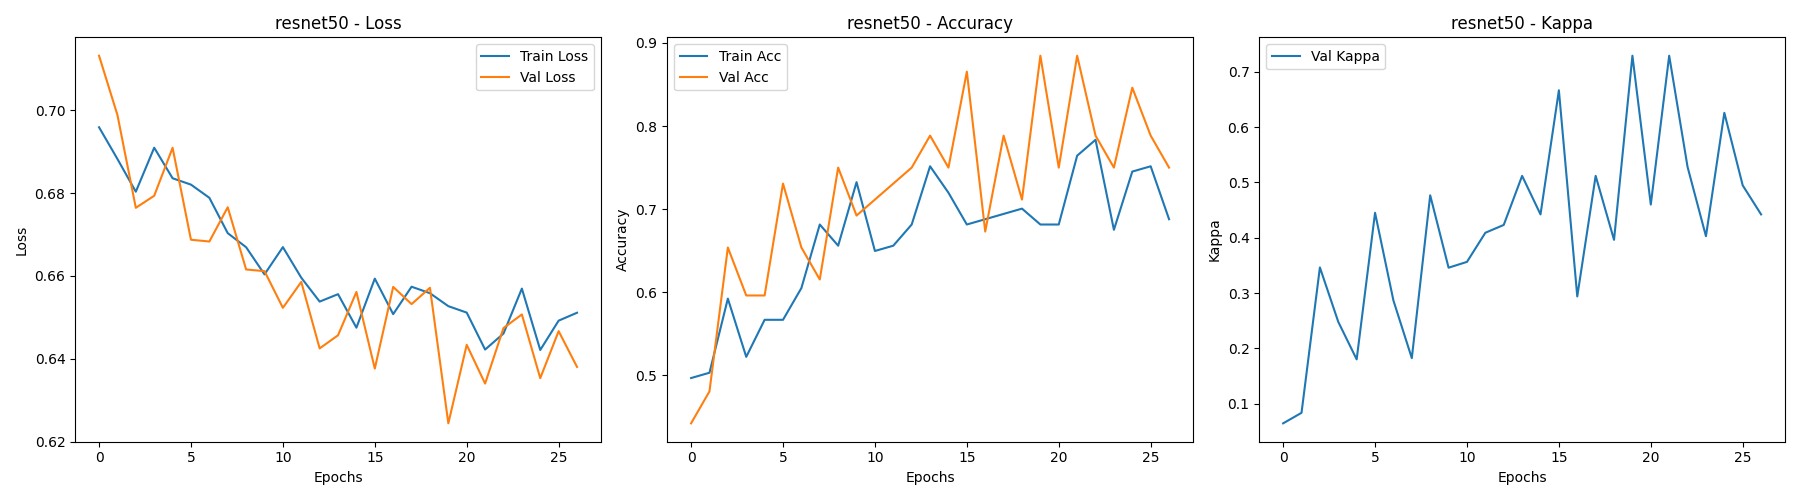

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/resnet50/confusion_matrix_resnet50.png


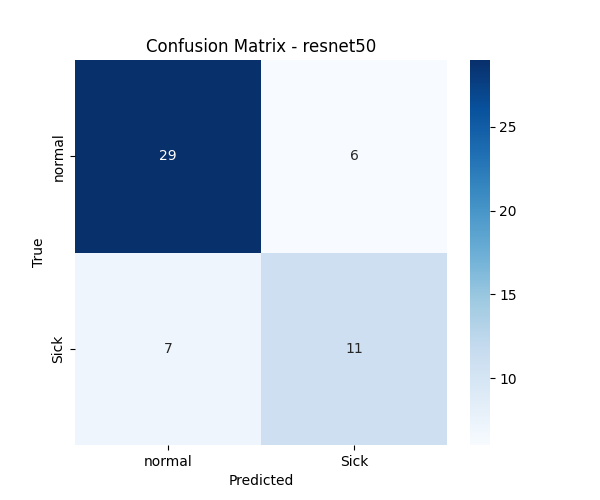

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/resnet50/roc_curve_resnet50.png


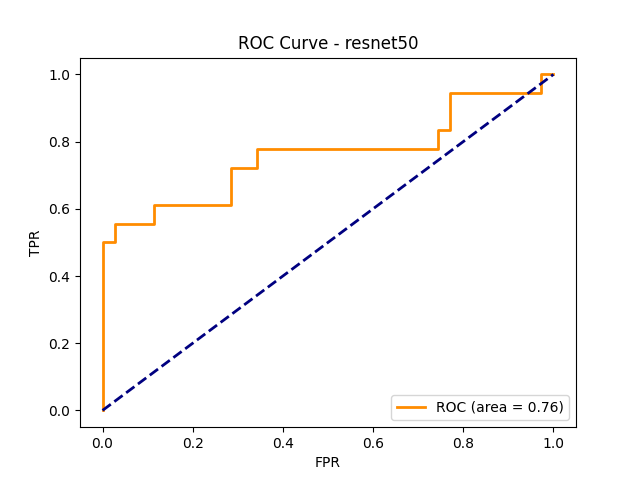

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/resnet50/tsne_plot_resnet50.png


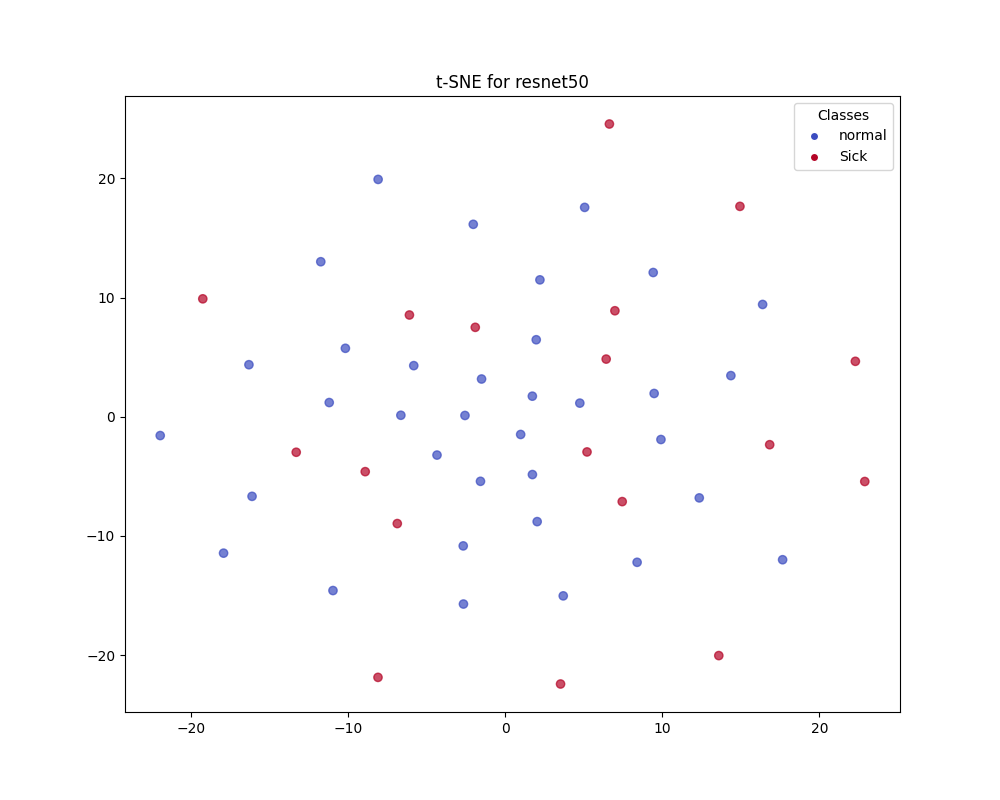

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/vgg16/training_plots_vgg16.png


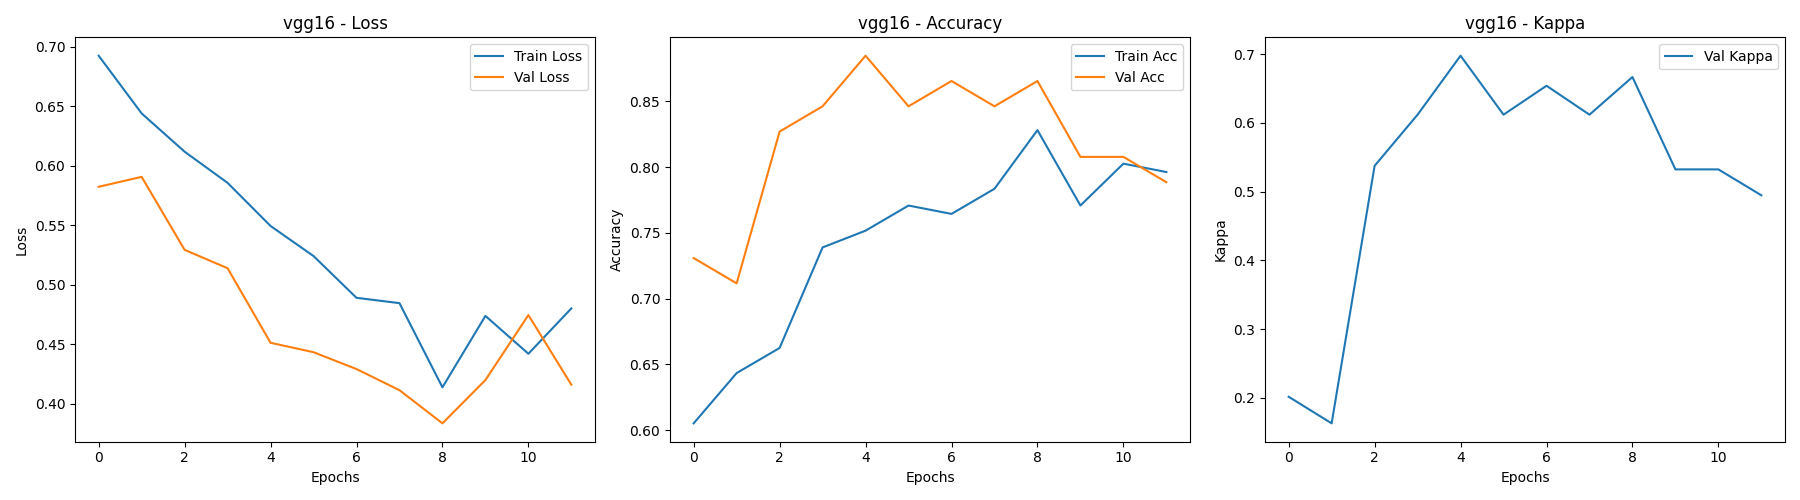

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/vgg16/confusion_matrix_vgg16.png


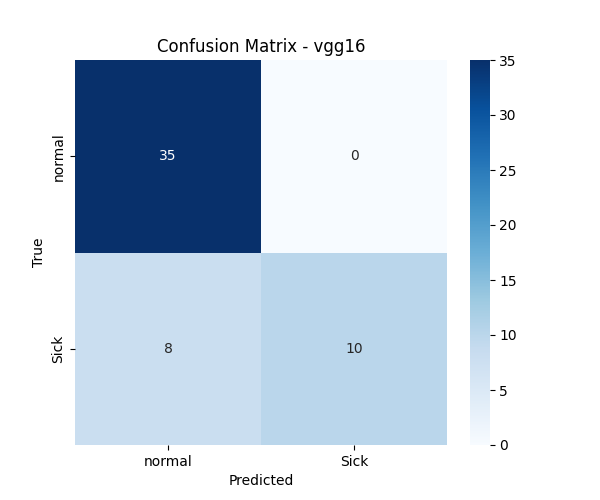

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/vgg16/roc_curve_vgg16.png


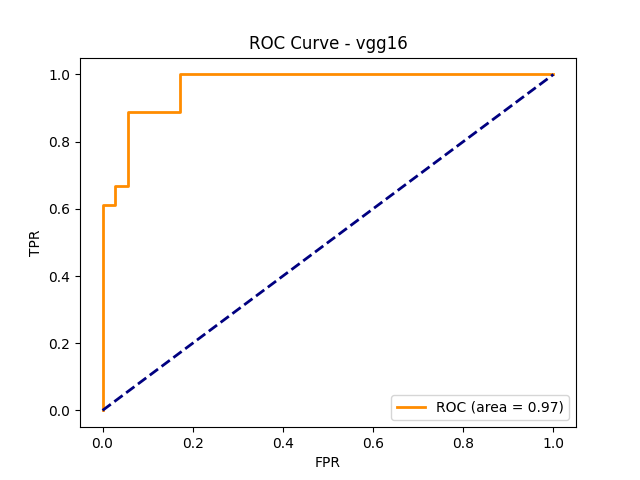

------------------------------


Displaying: /kaggle/working/experiment_outputs_best_kappa_per_model/vgg16/tsne_plot_vgg16.png


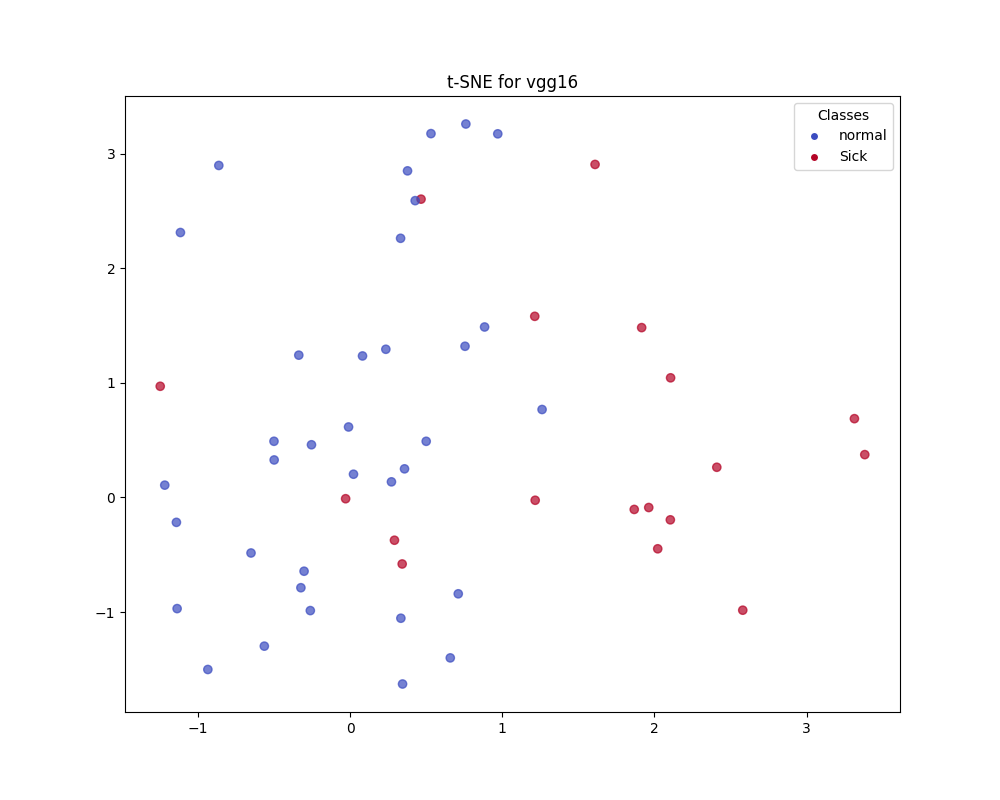

------------------------------


In [9]:
import os
from IPython.display import Image, display, HTML

# --- Configuration ---
# This MUST match the directory where your saved plot PNG files are
output_dir_base = "/kaggle/working/experiment_outputs_best_kappa_per_model" # Kaggle working directory
model_names_evaluated = ["cnn", "resnet18", "densenet121", "resnet50", "vgg16"]

# Expected plot filenames (these should match what your training script saved)
plot_filenames_templates = {
    "training_plots": "training_plots_{model_name}.png",
    "confusion_matrix": "confusion_matrix_{model_name}.png",
    "roc_curve": "roc_curve_{model_name}.png",
    "tsne_plot": "tsne_plot_{model_name}.png" # Or just tsne_plot.png if not model_name specific
}

if not os.path.isdir(output_dir_base):
    print(f"ERROR: Base output directory '{output_dir_base}' not found! Please check the path.")
else:
    print(f"Attempting to display plots from: {output_dir_base}\n")
    for model_name in model_names_evaluated:
        model_specific_output_dir = os.path.join(output_dir_base, model_name)
        
        display(HTML(f"<h2>--- Metrics for Model: {model_name.upper()} ---</h2>"))
        
        if not os.path.isdir(model_specific_output_dir):
            print(f"Directory for model {model_name} not found: {model_specific_output_dir}")
            continue

        # Display each expected plot type
        for plot_type, filename_template in plot_filenames_templates.items():
            # Construct the specific filename
            # Handle cases where model_name might not be in the t-SNE plot filename if it was saved differently
            if "{model_name}" in filename_template:
                plot_file_name = filename_template.format(model_name=model_name)
            else:
                plot_file_name = filename_template # e.g. if tsne_plot.png was saved without model name in it

            plot_file_path = os.path.join(model_specific_output_dir, plot_file_name)
            
            display(HTML(f"<h3>{plot_type.replace('_', ' ').title()}</h3>"))
            if os.path.exists(plot_file_path):
                try:
                    print(f"Displaying: {plot_file_path}")
                    display(Image(filename=plot_file_path, width=600)) # Adjust width as needed
                except Exception as e:
                    print(f"Error displaying image {plot_file_path}: {e}")
            else:
                # Try the generic name if the model-specific one wasn't found (e.g. for t-SNE sometimes)
                if "{model_name}" in filename_template:
                    generic_plot_file_name = filename_template.split("_{model_name}")[0] + ".png"
                    generic_plot_file_path = os.path.join(model_specific_output_dir, generic_plot_file_name)
                    if os.path.exists(generic_plot_file_path):
                        print(f"Displaying (fallback generic name): {generic_plot_file_path}")
                        display(Image(filename=generic_plot_file_path, width=600))
                    else:
                        print(f"Plot not found: {plot_file_path} (and generic fallback not found)")
                else:
                    print(f"Plot not found: {plot_file_path}")
            print("-" * 30)
        
        # Display the classification report text file content if it exists
        report_filename = f"classification_report_{model_name}.txt"
        report_file_path = os.path.join(model_specific_output_dir, report_filename)
        display(HTML(f"<h3>Classification Report</h3>"))
        if os.path.exists(report_file_path):
            try:
                with open(report_file_path, 'r') as f:
                    report_content = f.read()
                # Display with preformatted tag to maintain spacing
                display(HTML(f"<pre>{report_content}</pre>"))
            except Exception as e:
                print(f"Error reading report {report_file_path}: {e}")
        else:
            print(f"Classification report not found: {report_file_path}")
        print("\n" + "="*50 + "\n")

Using device: cuda
Clinical data loaded successfully. Shape: (119, 10)
Clinical data columns: ['Image', 'Left', 'Right', 'Weight (Kg)', 'Height(cm)', 'Temp(°C)', 'Age(years)', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']
First 5 rows of clinical data:
      Image Left Right  Weight (Kg)  Height(cm)  Temp(°C)  Age(years)  \
0  IIR0001   PB     N         45.6       156.0      36.2          19   
1  IIR0002    N    PB         61.6       160.6      36.6          33   
2  IIR0003    N    PB         46.2       172.5      36.0          18   
3  IIR0004   PB     N         82.3       163.9      35.6          26   
4  IIR0005   PB     N         59.6       163.0      36.5          26   

   Unnamed: 7  Unnamed: 8                                         Unnamed: 9  
0         NaN         NaN                                         N = Normal  
1         NaN         NaN  PB = Bening Patology (Some patology: collageni...  
2         NaN         NaN                   PM = Malign Patology (Carcinoma)  
3

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


Found 357 images from 119 unique patients with matching clinical data.
Dataset splits: Train: 249, Validation: 54, Test: 54


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s] 



Starting model training...


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/25 | Train Loss: 0.6755, Acc: 0.5703 | Val Loss: 0.6349, Acc: 0.7037, Kappa: 0.0924
Validation Kappa improved to 0.0924. Model saved to multimodal_breast_cancer_model_outputs/best_multimodal_model.pth
Epoch 2/25 | Train Loss: 0.6230, Acc: 0.6627 | Val Loss: 0.5876, Acc: 0.7222, Kappa: 0.2676
Validation Kappa improved to 0.2676. Model saved to multimodal_breast_cancer_model_outputs/best_multimodal_model.pth
Epoch 3/25 | Train Loss: 0.6020, Acc: 0.6667 | Val Loss: 0.6021, Acc: 0.6667, Kappa: 0.2546
Epoch 4/25 | Train Loss: 0.5640, Acc: 0.7430 | Val Loss: 0.5564, Acc: 0.7778, Kappa: 0.5031
Validation Kappa improved to 0.5031. Model saved to multimodal_breast_cancer_model_outputs/best_multimodal_model.pth
Epoch 5/25 | Train Loss: 0.5161, Acc: 0.7671 | Val Loss: 0.5873, Acc: 0.7037, Kappa: 0.3591
Epoch 6/25 | Train Loss: 0.4711, Acc: 0.8353 | Val Loss: 0.5650, Acc: 0.7222, Kappa: 0.3457
Epoch 7/25 | Train Loss: 0.4153, Acc: 0.8795 | Val Loss: 0.4595, Acc: 0.7778, Kappa: 0.4022
Epoch

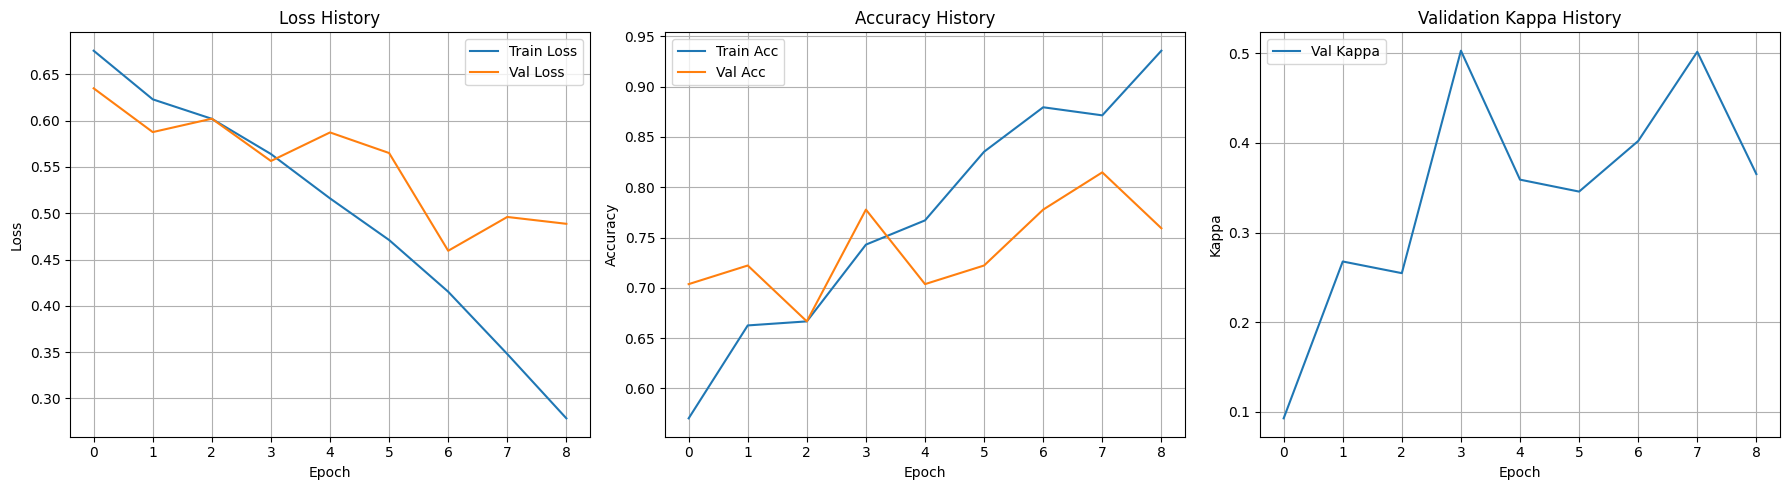


Evaluating on Test Set...
Loaded best model weights from multimodal_breast_cancer_model_outputs/best_multimodal_model.pth for evaluation.


/tmp/ipykernel_31/2532196650.py:382: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  multimodal_model.load_state_dict(torch.load(best_model_weights_path))



Test Set Evaluation:
               precision    recall  f1-score   support

   Benign (0)       0.86      0.82      0.84        38
Malignant (1)       0.61      0.69      0.65        16

     accuracy                           0.78        54
    macro avg       0.74      0.75      0.74        54
 weighted avg       0.79      0.78      0.78        54

Test Cohen's Kappa: 0.4857
Test ROC AUC Score: 0.8421


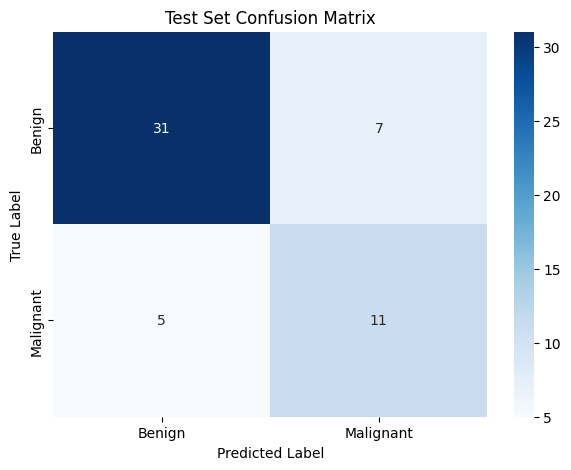

In [2]:
import os
import pandas as pd
import numpy as np
from PIL import Image # For loading images

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, cohen_kappa_score, roc_auc_score

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots are displayed inline in Jupyter/Kaggle
%matplotlib inline

# --- Configuration ---
SECOND_DATASET_PATH = r"/kaggle/input/bcd-mendeley-datset" # Base path for the dataset
IMAGE_DIR_BASE = os.path.join(SECOND_DATASET_PATH, "Breast Thermography")
# !!! IMPORTANT: Replace with the actual name of your Excel file !!!
EXCEL_FILE_NAME = "Breast Thermography/Diagnostics.xlsx" # EXAMPLE: Please verify this filename
EXCEL_FILE_PATH = os.path.join(SECOND_DATASET_PATH, EXCEL_FILE_NAME)

OUTPUT_MODEL_DIR = "multimodal_breast_cancer_model_outputs"
os.makedirs(OUTPUT_MODEL_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Model Hyperparameters (can be tuned)
IMG_SIZE = (224, 224) # Standard for many pre-trained models
BATCH_SIZE = 16 # Adjust based on GPU memory
LEARNING_RATE = 0.0001
NUM_EPOCHS = 25 # Start with this, can increase
EARLY_STOPPING_PATIENCE = 5
NUM_CLINICAL_FEATURES = 4 # Age, Weight, Height, Temp (after processing)


# --- 1. Load and Process Clinical Data ---
def load_clinical_data(excel_path):
    try:
        df_clinical = pd.read_excel(excel_path)
        print(f"Clinical data loaded successfully. Shape: {df_clinical.shape}")
        print("Clinical data columns:", df_clinical.columns.tolist())
        print("First 5 rows of clinical data:\n", df_clinical.head())
    except FileNotFoundError:
        print(f"ERROR: Clinical data file not found at {excel_path}")
        print("Please ensure EXCEL_FILE_NAME is correct and the file is in the specified path.")
        return None
    except Exception as e:
        print(f"Error loading clinical data: {e}")
        return None

    # Rename columns for easier access (adjust if your Excel has different names)
    # Expected columns based on your description:
    # 'Image', 'Weight (Kg)', 'Height(cm)', 'Temp(°C)', 'Age(years)', 'Left', 'Right'
    # The 'Image' column seems to be the Patient ID (e.g., IIR0001)
    
    # Let's try to be robust with column names
    column_map = {}
    for col in df_clinical.columns:
        col_lower = col.lower()
        if 'image' in col_lower or 'patient' in col_lower or 'id' in col_lower and 'iir' in df_clinical[col].astype(str).iloc[0].lower():
            column_map[col] = 'Patient_ID'
        elif 'weight' in col_lower:
            column_map[col] = 'Weight'
        elif 'height' in col_lower:
            column_map[col] = 'Height'
        elif 'temp' in col_lower:
            column_map[col] = 'Temperature'
        elif 'age' in col_lower:
            column_map[col] = 'Age'
        elif 'left' in col_lower:
            column_map[col] = 'Left_Breast'
        elif 'right' in col_lower:
            column_map[col] = 'Right_Breast'
            
    df_clinical = df_clinical.rename(columns=column_map)
    
    required_cols = ['Patient_ID', 'Weight', 'Height', 'Temperature', 'Age']
    if not all(col in df_clinical.columns for col in required_cols):
        print(f"ERROR: Missing one or more required clinical columns. Expected: {required_cols}. Found: {df_clinical.columns.tolist()}")
        print("Please check column names in your Excel file or adjust the renaming logic.")
        return None

    # Select and preprocess features
    # Convert Patient_ID to string if it's not already, for consistent matching
    df_clinical['Patient_ID'] = df_clinical['Patient_ID'].astype(str).str.strip()
    
    # Handle missing values (e.g., with mean imputation for numerical)
    for col in ['Weight', 'Height', 'Temperature', 'Age']:
        if df_clinical[col].isnull().any():
            print(f"Warning: Missing values found in '{col}'. Imputing with mean.")
            df_clinical[col] = pd.to_numeric(df_clinical[col], errors='coerce') # Ensure numeric
            df_clinical[col] = df_clinical[col].fillna(df_clinical[col].mean())
        df_clinical[col] = pd.to_numeric(df_clinical[col], errors='coerce') # Ensure numeric again

    # Normalize numerical features
    numerical_features = ['Weight', 'Height', 'Temperature', 'Age']
    scaler = StandardScaler()
    df_clinical[numerical_features] = scaler.fit_transform(df_clinical[numerical_features])
    
    # Create a dictionary for easy lookup: {Patient_ID: [features_array]}
    clinical_features_dict = {}
    for index, row in df_clinical.iterrows():
        features = row[numerical_features].values.astype(np.float32)
        clinical_features_dict[row['Patient_ID']] = features
        
    print(f"Processed {len(clinical_features_dict)} patients' clinical data.")
    # Example: print(list(clinical_features_dict.items())[:2])
    return clinical_features_dict

clinical_data_map = load_clinical_data(EXCEL_FILE_PATH)

# --- 2. Prepare Image Paths, Patient IDs, and Labels ---
def get_image_paths_and_labels(image_dir_base, clinical_data_map_keys):
    image_info = [] # List of (image_path, patient_id, label)
    patient_ids_from_images = set()

    if not os.path.isdir(image_dir_base):
        print(f"ERROR: Base image directory not found: {image_dir_base}")
        return image_info, patient_ids_from_images

    for label_name in ['Benign', 'Malignant']:
        label_dir = os.path.join(image_dir_base, label_name)
        if not os.path.isdir(label_dir):
            print(f"Warning: Label directory not found: {label_dir}")
            continue
            
        for patient_id_folder in os.listdir(label_dir):
            patient_folder_path = os.path.join(label_dir, patient_id_folder)
            if os.path.isdir(patient_folder_path):
                # Ensure patient_id from folder exists in clinical data
                if patient_id_folder not in clinical_data_map_keys:
                    # print(f"Warning: Patient ID {patient_id_folder} from image folders not found in clinical data. Skipping.")
                    continue # Skip if no clinical data for this patient
                
                patient_ids_from_images.add(patient_id_folder)
                for img_file in os.listdir(patient_folder_path):
                    if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
                        img_path = os.path.join(patient_folder_path, img_file)
                        # Label: 0 for Benign, 1 for Malignant
                        label = 0 if label_name == 'Benign' else 1
                        image_info.append((img_path, patient_id_folder, label))
                        
    print(f"Found {len(image_info)} images from {len(patient_ids_from_images)} unique patients with matching clinical data.")
    if not image_info:
        print("ERROR: No images found or no matching clinical data for patients found in image folders.")
        print("Check image paths, patient ID format consistency, and if clinical_data_map was populated.")
    return image_info, patient_ids_from_images

if clinical_data_map:
    all_image_data, patients_with_images = get_image_paths_and_labels(IMAGE_DIR_BASE, clinical_data_map.keys())
else:
    all_image_data = []
    patients_with_images = set()
    print("Skipping image path collection due to issues with clinical data loading.")

# --- 3. Custom PyTorch Dataset ---
class MultimodalDataset(Dataset):
    def __init__(self, image_info_list, clinical_features_map, transform=None):
        self.image_info_list = image_info_list
        self.clinical_features_map = clinical_features_map
        self.transform = transform

    def __len__(self):
        return len(self.image_info_list)

    def __getitem__(self, idx):
        img_path, patient_id, label = self.image_info_list[idx]
        
        # Load image
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return a dummy image and a flag or handle appropriately
            image = Image.new('RGB', IMG_SIZE, (0,0,0)) # Dummy black image
            # Or raise an error / return None and filter in collate_fn

        if self.transform:
            image = self.transform(image)
            
        # Get clinical features
        clinical_features = self.clinical_features_map.get(patient_id)
        if clinical_features is None:
            # This should ideally not happen if data was prepared correctly
            print(f"Critical Error: Clinical features not found for patient {patient_id} at getitem for image {img_path}")
            clinical_features = np.zeros(NUM_CLINICAL_FEATURES, dtype=np.float32) # Fallback
            
        return image, torch.tensor(clinical_features, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

# Image transformations
image_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

if all_image_data:
    # Split data: 70% train, 15% validation, 15% test
    train_val_data, test_data = train_test_split(all_image_data, test_size=0.15, random_state=42, stratify=[item[2] for item in all_image_data])
    train_data, val_data = train_test_split(train_val_data, test_size=(0.15/0.85), random_state=42, stratify=[item[2] for item in train_val_data]) # 0.15/0.85 is ~0.176 for 15% of original

    train_dataset = MultimodalDataset(train_data, clinical_data_map, transform=image_transform)
    val_dataset = MultimodalDataset(val_data, clinical_data_map, transform=image_transform) # Use simpler transform for val/test if needed
    test_dataset = MultimodalDataset(test_data, clinical_data_map, transform=transforms.Compose([transforms.Resize(IMG_SIZE), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]))

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"Dataset splits: Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}")
    if len(train_dataset) == 0:
         print("ERROR: Training dataset is empty. Check data loading and splitting.")
else:
    print("Cannot proceed to model definition as data loading failed or found no data.")


# --- 4. Multimodal Model Architecture ---
class MultimodalBreastCancerCNN(nn.Module):
    def __init__(self, num_clinical_features, num_classes=1, dropout_rate=0.4):
        super(MultimodalBreastCancerCNN, self).__init__()
        
        # Image Branch (using ResNet18)
        self.image_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        num_ftrs_img = self.image_model.fc.in_features
        self.image_model.fc = nn.Identity() # Remove original FC layer

        # Clinical Data Branch
        self.clinical_mlp = nn.Sequential(
            nn.Linear(num_clinical_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU()
        )
        
        # Fusion and Classifier Head
        # Concatenated features: image features + clinical features
        # Assuming image_model outputs num_ftrs_img, and clinical_mlp outputs 32
        self.fusion_dropout = nn.Dropout(dropout_rate + 0.1) # Slightly higher dropout after fusion
        self.classifier = nn.Sequential(
            nn.Linear(num_ftrs_img + 32, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes) # Output 1 logit for BCELossWithLogits
        )

    def forward(self, image_input, clinical_input):
        image_features = self.image_model(image_input)       # Shape: (batch_size, num_ftrs_img)
        clinical_features = self.clinical_mlp(clinical_input) # Shape: (batch_size, 32)
        
        # Concatenate features
        fused_features = torch.cat((image_features, clinical_features), dim=1)
        fused_features = self.fusion_dropout(fused_features)
        
        output_logits = self.classifier(fused_features)
        return output_logits # Return logits

if all_image_data and len(train_dataset) > 0 : # Proceed only if data is loaded
    # Instantiate the model
    # num_classes = 1 because we'll use BCELossWithLogitsLoss (expects raw logits)
    # and sigmoid will be applied outside or implicitly by the loss function
    multimodal_model = MultimodalBreastCancerCNN(num_clinical_features=NUM_CLINICAL_FEATURES, num_classes=1).to(DEVICE)

    # --- 5. Training Loop ---
    criterion = nn.BCEWithLogitsLoss() # Numerically more stable than Sigmoid + BCELoss
    optimizer = optim.Adam(multimodal_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5) # Added L2 regularization
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.2, verbose=True)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_kappa': []}
    best_val_kappa = -float('inf')
    epochs_no_improve = 0
    best_model_weights_path = os.path.join(OUTPUT_MODEL_DIR, "best_multimodal_model.pth")

    print("\nStarting model training...")
    for epoch in range(NUM_EPOCHS):
        multimodal_model.train()
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, clinical_data, labels in train_loader:
            images, clinical_data, labels = images.to(DEVICE), clinical_data.to(DEVICE), labels.to(DEVICE).float().unsqueeze(1)
            
            optimizer.zero_grad()
            outputs_logits = multimodal_model(images, clinical_data)
            loss = criterion(outputs_logits, labels)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item() * images.size(0)
            preds_binary = (torch.sigmoid(outputs_logits) > 0.5).float()
            correct_train += (preds_binary == labels).sum().item()
            total_train += labels.size(0)
            
        epoch_train_loss = running_train_loss / total_train
        epoch_train_acc = correct_train / total_train
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)

        multimodal_model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        all_val_labels = []
        all_val_preds = []
        with torch.no_grad():
            for images, clinical_data, labels in val_loader:
                images, clinical_data, labels = images.to(DEVICE), clinical_data.to(DEVICE), labels.to(DEVICE).float().unsqueeze(1)
                outputs_logits = multimodal_model(images, clinical_data)
                loss = criterion(outputs_logits, labels)
                running_val_loss += loss.item() * images.size(0)
                
                preds_binary = (torch.sigmoid(outputs_logits) > 0.5).float()
                correct_val += (preds_binary == labels).sum().item()
                total_val += labels.size(0)
                all_val_labels.extend(labels.cpu().numpy().flatten().tolist())
                all_val_preds.extend(preds_binary.cpu().numpy().flatten().tolist())

        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc = correct_val / total_val
        epoch_val_kappa = 0.0
        if len(all_val_labels) > 0 and len(np.unique(all_val_labels)) > 1: # Kappa only if multiple classes present
            epoch_val_kappa = cohen_kappa_score(all_val_labels, all_val_preds)
        elif len(all_val_labels) > 0 and len(np.unique(all_val_labels)) == 1 and len(np.unique(all_val_preds)) == 1 and np.unique(all_val_labels)[0] == np.unique(all_val_preds)[0]:
            epoch_val_kappa = 1.0


        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)
        history['val_kappa'].append(epoch_val_kappa)
        
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}, Kappa: {epoch_val_kappa:.4f}")
        
        scheduler.step(epoch_val_loss) # Step scheduler on val loss

        if epoch_val_kappa > best_val_kappa:
            best_val_kappa = epoch_val_kappa
            epochs_no_improve = 0
            torch.save(multimodal_model.state_dict(), best_model_weights_path)
            print(f"Validation Kappa improved to {best_val_kappa:.4f}. Model saved to {best_model_weights_path}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping at epoch {epoch+1}. Best Val Kappa: {best_val_kappa:.4f}")
                break
    
    print("Training finished.")

    # --- Plot Training History ---
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(history['train_loss'], label='Train Loss'); plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss History'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
    plt.subplot(1, 3, 2)
    plt.plot(history['train_acc'], label='Train Acc'); plt.plot(history['val_acc'], label='Val Acc')
    plt.title('Accuracy History'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)
    plt.subplot(1, 3, 3)
    plt.plot(history['val_kappa'], label='Val Kappa')
    plt.title('Validation Kappa History'); plt.xlabel('Epoch'); plt.ylabel('Kappa'); plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_MODEL_DIR, "training_history.png"))
    plt.show()

    # --- 6. Evaluation on Test Set ---
    print("\nEvaluating on Test Set...")
    if os.path.exists(best_model_weights_path):
        multimodal_model.load_state_dict(torch.load(best_model_weights_path))
        print(f"Loaded best model weights from {best_model_weights_path} for evaluation.")
    else:
        print("Warning: No best model weights found. Evaluating with the last state of the model.")
        
    multimodal_model.eval()
    y_true_test, y_pred_test, y_pred_probs_test = [], [], []
    with torch.no_grad():
        for images, clinical_data, labels in test_loader:
            images, clinical_data, labels = images.to(DEVICE), clinical_data.to(DEVICE), labels.to(DEVICE)
            outputs_logits = multimodal_model(images, clinical_data)
            
            probs = torch.sigmoid(outputs_logits).cpu().numpy().flatten()
            preds_binary = (probs > 0.5).astype(int)
            
            y_true_test.extend(labels.cpu().numpy().flatten().tolist())
            y_pred_test.extend(preds_binary.tolist())
            y_pred_probs_test.extend(probs.tolist())

    print("\nTest Set Evaluation:")
    print(classification_report(y_true_test, y_pred_test, target_names=['Benign (0)', 'Malignant (1)'], zero_division=0))
    test_kappa = cohen_kappa_score(y_true_test, y_pred_test)
    print(f"Test Cohen's Kappa: {test_kappa:.4f}")
    try:
        if len(np.unique(y_true_test)) > 1: # ROC AUC requires multiple classes in y_true
            test_roc_auc = roc_auc_score(y_true_test, y_pred_probs_test)
            print(f"Test ROC AUC Score: {test_roc_auc:.4f}")
    except ValueError as e_auc:
        print(f"Could not calculate ROC AUC: {e_auc}")


    # Confusion Matrix for Test Set
    cm = confusion_matrix(y_true_test, y_pred_test)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.title('Test Set Confusion Matrix')
    plt.savefig(os.path.join(OUTPUT_MODEL_DIR, "test_confusion_matrix.png"))
    plt.show()

else:
    print("Model training and evaluation skipped due to data loading issues or empty dataset.")

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os



# --- Load Clinical Data ---
try:
    df_clinical_for_scaling = pd.read_excel(EXCEL_FILE_PATH)
    print(f"Clinical data for scaling loaded successfully. Shape: {df_clinical_for_scaling.shape}")
    print("Columns:", df_clinical_for_scaling.columns.tolist())
except FileNotFoundError:
    print(f"ERROR: Clinical data file not found at {EXCEL_FILE_PATH}")
    print("Please ensure EXCEL_FILE_NAME and path are correct.")
    exit()
except Exception as e:
    print(f"Error loading clinical data: {e}")
    exit()

# --- Rename columns to match what your multimodal training script used ---
# This renaming logic should be consistent with your training script.
column_map_scaling = {}
for col in df_clinical_for_scaling.columns:
    col_lower = col.lower()
    if 'image' in col_lower or 'patient' in col_lower or 'id' in col_lower and 'iir' in df_clinical_for_scaling[col].astype(str).iloc[0].lower():
        column_map_scaling[col] = 'Patient_ID'
    elif 'weight' in col_lower:
        column_map_scaling[col] = 'Weight'
    elif 'height' in col_lower:
        column_map_scaling[col] = 'Height'
    elif 'temp' in col_lower:
        column_map_scaling[col] = 'Temperature'
    elif 'age' in col_lower:
        column_map_scaling[col] = 'Age'
        
df_clinical_for_scaling = df_clinical_for_scaling.rename(columns=column_map_scaling)

# --- Select Numerical Features for Scaling ---
# These MUST be the exact same features and in the same order as used for training the multimodal model.
numerical_feature_names = ['Age', 'Weight', 'Height', 'Temperature'] # The order matters!

if not all(col in df_clinical_for_scaling.columns for col in numerical_feature_names):
    print(f"ERROR: Missing one or more required columns for scaling: {numerical_feature_names}. Found: {df_clinical_for_scaling.columns.tolist()}")
    print("Please check column names in your Excel file or adjust the renaming/selection logic.")
    exit()

df_numerical_features = df_clinical_for_scaling[numerical_feature_names].copy()

# --- Handle Missing Values (same way as in training) ---
# Example: Mean imputation
for col in numerical_feature_names:
    # Ensure column is numeric, coercing errors. This can introduce NaNs if non-numeric values exist.
    df_numerical_features[col] = pd.to_numeric(df_numerical_features[col], errors='coerce')
    if df_numerical_features[col].isnull().any():
        print(f"Warning: Missing values found in '{col}'. Imputing with mean.")
        mean_val = df_numerical_features[col].mean()
        df_numerical_features[col] = df_numerical_features[col].fillna(mean_val)

# Double-check for any remaining NaNs after imputation (should not happen if imputation is done correctly)
if df_numerical_features.isnull().values.any():
    print("ERROR: NaNs still present after imputation. Check data and imputation logic.")
    print(df_numerical_features[df_numerical_features.isnull().any(axis=1)])
    exit()

# --- Fit the StandardScaler ---
# IMPORTANT: In a real training pipeline, you would fit this scaler ONLY on your TRAINING DATA SPLIT.
# If you used the entire clinical dataset to fit the scaler before splitting for training,
# then using the whole dataset here to get the parameters is okay for consistency with that.
# However, the best practice is to fit on the training split only.

scaler = StandardScaler()
scaler.fit(df_numerical_features) # Fit on the selected numerical features

# --- Get and Print the Parameters ---
means = scaler.mean_
stds = scaler.scale_ # Standard deviation

print("\n--- Scaling Parameters ---")
print(f"Features in order: {numerical_feature_names}")
print(f"Means (CLINICAL_MEANS): {means.tolist()}")
print(f"Standard Deviations (CLINICAL_STDS): {stds.tolist()}")

print("\n--- For your app.py ---")
print(f"CLINICAL_MEANS = np.array({means.tolist()})")
print(f"CLINICAL_STDS = np.array({stds.tolist()})")
print("NUM_CLINICAL_FEATURES should be:", len(numerical_feature_names))

Clinical data for scaling loaded successfully. Shape: (119, 10)
Columns: ['Image', 'Left', 'Right', 'Weight (Kg)', 'Height(cm)', 'Temp(°C)', 'Age(years)', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']

--- Scaling Parameters ---
Features in order: ['Age', 'Weight', 'Height', 'Temperature']
Means (CLINICAL_MEANS): [48.714285714285715, 72.26470588235294, 157.05714285714285, 35.99915966386554]
Standard Deviations (CLINICAL_STDS): [13.102147400582952, 16.884768076012232, 7.137068242439532, 0.4296756248318925]

--- For your app.py ---
CLINICAL_MEANS = np.array([48.714285714285715, 72.26470588235294, 157.05714285714285, 35.99915966386554])
CLINICAL_STDS = np.array([13.102147400582952, 16.884768076012232, 7.137068242439532, 0.4296756248318925])
NUM_CLINICAL_FEATURES should be: 4


Using device: cuda
Found 357 images from 119 unique patients for Grad-CAM model training.
Grad-CAM Model Dataset splits: Train: 249, Validation: 54, Test: 54

Starting DenseNet121 (for Grad-CAM) model training...


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/300 | Train Loss: 0.7103, Acc: 0.4699 | Val Loss: 0.7351, Acc: 0.3333, Kappa: -0.0611
Val Kappa improved to -0.0611. Model saved.
Epoch 2/300 | Train Loss: 0.6562, Acc: 0.6426 | Val Loss: 0.6562, Acc: 0.6852, Kappa: 0.2312
Val Kappa improved to 0.2312. Model saved.
Epoch 3/300 | Train Loss: 0.6102, Acc: 0.7068 | Val Loss: 0.6428, Acc: 0.7407, Kappa: 0.3026
Val Kappa improved to 0.3026. Model saved.
Epoch 4/300 | Train Loss: 0.5969, Acc: 0.7068 | Val Loss: 0.6002, Acc: 0.7593, Kappa: 0.2452
Epoch 5/300 | Train Loss: 0.5839, Acc: 0.7149 | Val Loss: 0.5869, Acc: 0.7778, Kappa: 0.3193
Val Kappa improved to 0.3193. Model saved.
Epoch 6/300 | Train Loss: 0.5631, Acc: 0.7269 | Val Loss: 0.5878, Acc: 0.7407, Kappa: 0.1674
Epoch 7/300 | Train Loss: 0.5772, Acc: 0.7309 | Val Loss: 0.5667, Acc: 0.7407, Kappa: 0.1674
Epoch 8/300 | Train Loss: 0.5420, Acc: 0.7390 | Val Loss: 0.5520, Acc: 0.7593, Kappa: 0.2452
Epoch 9/300 | Train Loss: 0.5406, Acc: 0.7229 | Val Loss: 0.5672, Acc: 0.7407, Kap

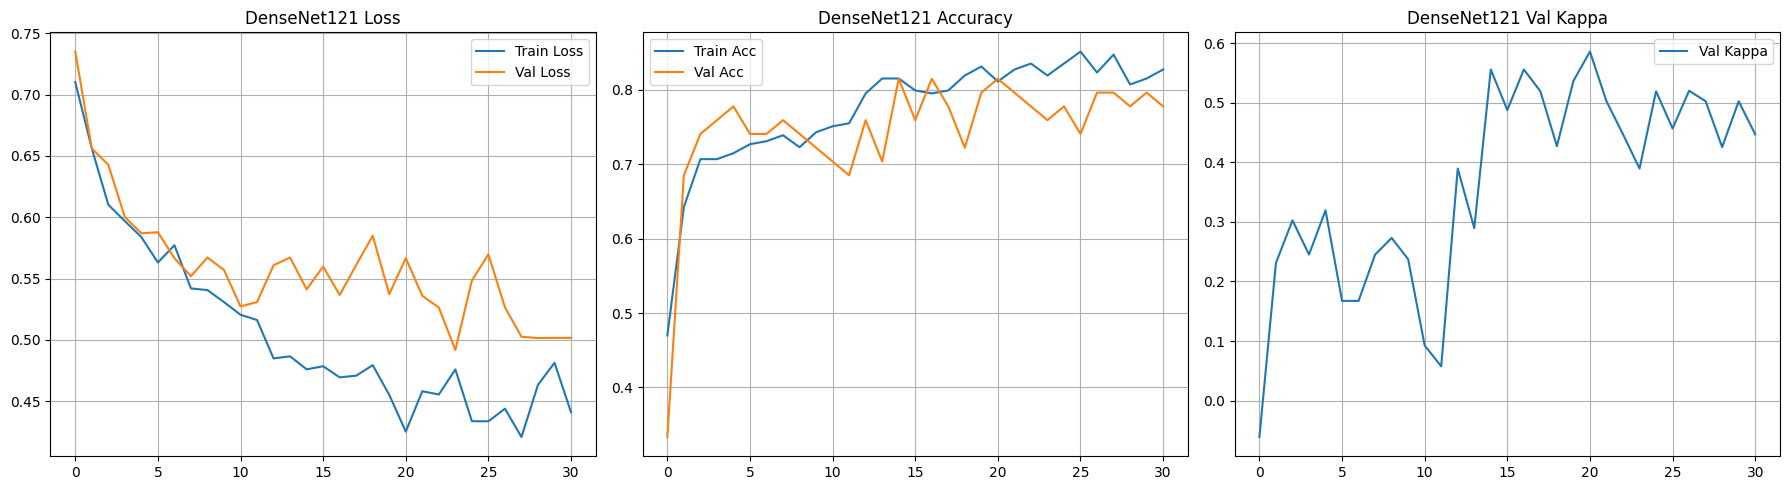


Evaluating DenseNet121 (for Grad-CAM) on its Test Set...


/tmp/ipykernel_31/2239250337.py:217: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gradcam_cnn_model.load_state_dict(torch.load(best_model_weights_path_gc))



DenseNet121 Test Set Evaluation:
               precision    recall  f1-score   support

   Benign (0)       0.88      0.79      0.83        38
Malignant (1)       0.60      0.75      0.67        16

     accuracy                           0.78        54
    macro avg       0.74      0.77      0.75        54
 weighted avg       0.80      0.78      0.78        54

DenseNet121 Test Cohen's Kappa: 0.5031
DenseNet121 Test ROC AUC Score: 0.8174


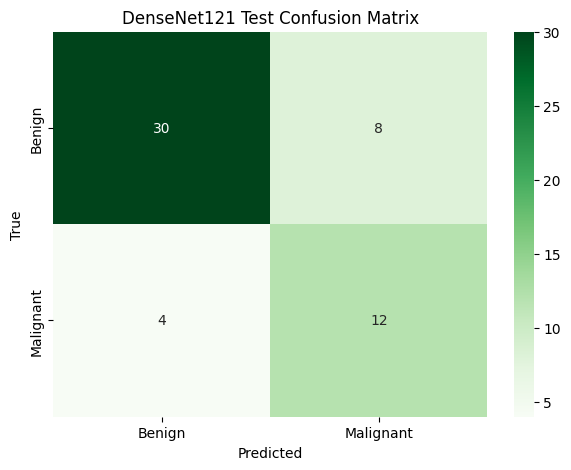

In [3]:
import os
import pandas as pd
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, cohen_kappa_score, roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure plots are displayed inline in Jupyter/Kaggle
%matplotlib inline

# --- Configuration ---
SECOND_DATASET_PATH = r"/kaggle/input/bcd-mendeley-datset" # Base path for the dataset
IMAGE_DIR_BASE = os.path.join(SECOND_DATASET_PATH, "Breast Thermography")

OUTPUT_GRADCAM_MODEL_DIR = "densenet121_for_gradcam_outputs"
os.makedirs(OUTPUT_GRADCAM_MODEL_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# Model Hyperparameters
IMG_SIZE = (224, 224) # DenseNet121 typically uses 224x224
BATCH_SIZE = 2
LEARNING_RATE = 0.00001 # Can be tuned
NUM_EPOCHS = 300 # Start with this, can increase/decrease
EARLY_STOPPING_PATIENCE = 10


# --- 1. Prepare Image Paths and Labels (No clinical data needed here) ---
def get_image_paths_and_labels_for_gradcam_model(image_dir_base):
    image_info = [] # List of (image_path, label)
    patient_ids_from_images = set() # Just to count unique patients if desired

    if not os.path.isdir(image_dir_base):
        print(f"ERROR: Base image directory not found: {image_dir_base}")
        return image_info

    for label_name in ['Benign', 'Malignant']:
        label_dir = os.path.join(image_dir_base, label_name)
        if not os.path.isdir(label_dir):
            print(f"Warning: Label directory not found: {label_dir}")
            continue
            
        for patient_id_folder in os.listdir(label_dir):
            patient_folder_path = os.path.join(label_dir, patient_id_folder)
            if os.path.isdir(patient_folder_path):
                patient_ids_from_images.add(patient_id_folder)
                for img_file in os.listdir(patient_folder_path):
                    if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
                        img_path = os.path.join(patient_folder_path, img_file)
                        label = 0 if label_name == 'Benign' else 1 # 0 for Benign, 1 for Malignant
                        image_info.append((img_path, label))
                        
    print(f"Found {len(image_info)} images from {len(patient_ids_from_images)} unique patients for Grad-CAM model training.")
    if not image_info:
        print("ERROR: No images found for Grad-CAM model training.")
    return image_info

all_image_data_gradcam = get_image_paths_and_labels_for_gradcam_model(IMAGE_DIR_BASE)

# --- 2. Custom PyTorch Dataset (Simpler: Image Only) ---
class ImageOnlyDataset(Dataset):
    def __init__(self, image_info_list, transform=None):
        self.image_info_list = image_info_list
        self.transform = transform

    def __len__(self):
        return len(self.image_info_list)

    def __getitem__(self, idx):
        img_path, label = self.image_info_list[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            image = Image.new('RGB', IMG_SIZE, (0,0,0)) # Dummy

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

# Image transformations
image_transform_train = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

image_transform_val_test = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

if all_image_data_gradcam:
    train_val_data_gc, test_data_gc = train_test_split(all_image_data_gradcam, test_size=0.15, random_state=42, stratify=[item[1] for item in all_image_data_gradcam])
    train_data_gc, val_data_gc = train_test_split(train_val_data_gc, test_size=(0.15/0.85), random_state=42, stratify=[item[1] for item in train_val_data_gc])

    train_dataset_gc = ImageOnlyDataset(train_data_gc, transform=image_transform_train)
    val_dataset_gc = ImageOnlyDataset(val_data_gc, transform=image_transform_val_test)
    test_dataset_gc = ImageOnlyDataset(test_data_gc, transform=image_transform_val_test)

    train_loader_gc = DataLoader(train_dataset_gc, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader_gc = DataLoader(val_dataset_gc, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader_gc = DataLoader(test_dataset_gc, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"Grad-CAM Model Dataset splits: Train: {len(train_dataset_gc)}, Validation: {len(val_dataset_gc)}, Test: {len(test_dataset_gc)}")
    if len(train_dataset_gc) == 0:
         print("ERROR: Grad-CAM model training dataset is empty.")
else:
    print("Cannot proceed to Grad-CAM model definition as data loading failed.")


# --- 3. Model Definition (DenseNet121) ---
def get_densenet121_for_gradcam(num_classes=1, pretrained=True): # num_classes=1 for BCELossWithLogits
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT if pretrained else None)
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Linear(num_ftrs, num_classes) # Replace classifier
    return model

if all_image_data_gradcam and len(train_dataset_gc) > 0:
    gradcam_cnn_model = get_densenet121_for_gradcam(num_classes=1).to(DEVICE)

    # --- 4. Training Loop ---
    criterion_gc = nn.BCEWithLogitsLoss()
    optimizer_gc = optim.Adam(gradcam_cnn_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
    scheduler_gc = optim.lr_scheduler.ReduceLROnPlateau(optimizer_gc, 'min', patience=3, factor=0.2, verbose=True)

    history_gc = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_kappa': []}
    best_val_kappa_gc = -float('inf')
    epochs_no_improve_gc = 0
    best_model_weights_path_gc = os.path.join(OUTPUT_GRADCAM_MODEL_DIR, "best_densenet121_for_gradcam.pth")

    print("\nStarting DenseNet121 (for Grad-CAM) model training...")
    for epoch in range(NUM_EPOCHS):
        gradcam_cnn_model.train()
        running_train_loss_gc, correct_train_gc, total_train_gc = 0.0, 0, 0
        for images, labels in train_loader_gc:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float().unsqueeze(1)
            optimizer_gc.zero_grad()
            outputs_logits = gradcam_cnn_model(images)
            loss = criterion_gc(outputs_logits, labels)
            loss.backward(); optimizer_gc.step()
            running_train_loss_gc += loss.item() * images.size(0)
            preds_binary = (torch.sigmoid(outputs_logits) > 0.5).float()
            correct_train_gc += (preds_binary == labels).sum().item()
            total_train_gc += labels.size(0)
        epoch_train_loss_gc = running_train_loss_gc / total_train_gc if total_train_gc > 0 else 0
        epoch_train_acc_gc = correct_train_gc / total_train_gc if total_train_gc > 0 else 0
        history_gc['train_loss'].append(epoch_train_loss_gc)
        history_gc['train_acc'].append(epoch_train_acc_gc)

        gradcam_cnn_model.eval()
        running_val_loss_gc, correct_val_gc, total_val_gc = 0.0, 0, 0
        all_val_labels_gc, all_val_preds_gc = [], []
        with torch.no_grad():
            for images, labels in val_loader_gc:
                images, labels = images.to(DEVICE), labels.to(DEVICE).float().unsqueeze(1)
                outputs_logits = gradcam_cnn_model(images)
                loss = criterion_gc(outputs_logits, labels)
                running_val_loss_gc += loss.item() * images.size(0)
                preds_binary = (torch.sigmoid(outputs_logits) > 0.5).float()
                correct_val_gc += (preds_binary == labels).sum().item()
                total_val_gc += labels.size(0)
                all_val_labels_gc.extend(labels.cpu().numpy().flatten().tolist())
                all_val_preds_gc.extend(preds_binary.cpu().numpy().flatten().tolist())
        epoch_val_loss_gc = running_val_loss_gc / total_val_gc if total_val_gc > 0 else 0
        epoch_val_acc_gc = correct_val_gc / total_val_gc if total_val_gc > 0 else 0
        epoch_val_kappa_gc = 0.0
        if len(all_val_labels_gc) > 0 and len(np.unique(all_val_labels_gc)) > 1:
            epoch_val_kappa_gc = cohen_kappa_score(all_val_labels_gc, all_val_preds_gc)
        elif len(all_val_labels_gc) > 0 and len(np.unique(all_val_labels_gc)) == 1 and len(np.unique(all_val_preds_gc)) == 1 and np.unique(all_val_labels_gc)[0] == np.unique(all_val_preds_gc)[0]:
            epoch_val_kappa_gc = 1.0


        history_gc['val_loss'].append(epoch_val_loss_gc)
        history_gc['val_acc'].append(epoch_val_acc_gc)
        history_gc['val_kappa'].append(epoch_val_kappa_gc)
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {epoch_train_loss_gc:.4f}, Acc: {epoch_train_acc_gc:.4f} | Val Loss: {epoch_val_loss_gc:.4f}, Acc: {epoch_val_acc_gc:.4f}, Kappa: {epoch_val_kappa_gc:.4f}")
        scheduler_gc.step(epoch_val_loss_gc)
        if epoch_val_kappa_gc > best_val_kappa_gc:
            best_val_kappa_gc = epoch_val_kappa_gc
            epochs_no_improve_gc = 0
            torch.save(gradcam_cnn_model.state_dict(), best_model_weights_path_gc)
            print(f"Val Kappa improved to {best_val_kappa_gc:.4f}. Model saved.")
        else:
            epochs_no_improve_gc += 1
            if epochs_no_improve_gc >= EARLY_STOPPING_PATIENCE:
                print(f"Early stopping at epoch {epoch+1}. Best Val Kappa: {best_val_kappa_gc:.4f}")
                break
    print(f"DenseNet121 (for Grad-CAM) training finished. Best model saved to {best_model_weights_path_gc}")

    # --- Plot Training History for Grad-CAM Model ---
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1); plt.plot(history_gc['train_loss'], label='Train Loss'); plt.plot(history_gc['val_loss'], label='Val Loss'); plt.title('DenseNet121 Loss'); plt.legend(); plt.grid(True)
    plt.subplot(1, 3, 2); plt.plot(history_gc['train_acc'], label='Train Acc'); plt.plot(history_gc['val_acc'], label='Val Acc'); plt.title('DenseNet121 Accuracy'); plt.legend(); plt.grid(True)
    plt.subplot(1, 3, 3); plt.plot(history_gc['val_kappa'], label='Val Kappa'); plt.title('DenseNet121 Val Kappa'); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_GRADCAM_MODEL_DIR, "densenet121_training_history.png")); plt.show()

    # --- Evaluation of Grad-CAM Model on its Test Set ---
    print("\nEvaluating DenseNet121 (for Grad-CAM) on its Test Set...")
    if os.path.exists(best_model_weights_path_gc):
        gradcam_cnn_model.load_state_dict(torch.load(best_model_weights_path_gc))
    gradcam_cnn_model.eval()
    y_true_gc_test, y_pred_gc_test, y_pred_probs_gc_test = [], [], []
    with torch.no_grad():
        for images, labels in test_loader_gc:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs_logits = gradcam_cnn_model(images)
            probs = torch.sigmoid(outputs_logits).cpu().numpy().flatten()
            preds_binary = (probs > 0.5).astype(int)
            y_true_gc_test.extend(labels.cpu().numpy().flatten().tolist())
            y_pred_gc_test.extend(preds_binary.tolist())
            y_pred_probs_gc_test.extend(probs.tolist())
    print("\nDenseNet121 Test Set Evaluation:")
    print(classification_report(y_true_gc_test, y_pred_gc_test, target_names=['Benign (0)', 'Malignant (1)'], zero_division=0))
    test_kappa_gc = cohen_kappa_score(y_true_gc_test, y_pred_gc_test)
    print(f"DenseNet121 Test Cohen's Kappa: {test_kappa_gc:.4f}")
    try:
        if len(np.unique(y_true_gc_test)) > 1:
            test_roc_auc_gc = roc_auc_score(y_true_gc_test, y_pred_probs_gc_test)
            print(f"DenseNet121 Test ROC AUC Score: {test_roc_auc_gc:.4f}")
    except ValueError as e_auc: print(f"Could not calculate ROC AUC for DenseNet121: {e_auc}")
    cm_gc = confusion_matrix(y_true_gc_test, y_pred_gc_test)
    plt.figure(figsize=(7, 5)); sns.heatmap(cm_gc, annot=True, fmt='d', cmap='Greens', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('DenseNet121 Test Confusion Matrix')
    plt.savefig(os.path.join(OUTPUT_GRADCAM_MODEL_DIR, "densenet121_test_confusion_matrix.png")); plt.show()
else:
    print("DenseNet121 (for Grad-CAM) model training and evaluation skipped.")